# Establish a semantic subspace - TODOs

- test differing amounts of context (local and relationship)
- clean up some of the differences between naming conventions...
- think about doing leave one subject out fitting so that the model optimally captures trajectories through the task... could really just simulate many different trajectories in the task maybe, so it doesnt depend on participant behavior at all? Then use that model in fitting the fMRI? would be directly converting the task into semantic space 

In [1]:
from utils import *
from utils_fmri import * 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from scipy.stats import kendalltau, pearsonr, ttest_1samp, ttest_rel
from scipy.spatial.distance import cosine


results_dir = '../results/semantic-space'

# use measure
data['frac_yrs_using'] = data['coc_dur_years'] / data['age_years']

# new dots measures
data['beh_dots_dist_zscore'] = (
    data['beh_dots_dist_mean'] - data['beh_dots_dist_shuff_mean']
) / data['beh_dots_dist_shuff_std']

#---------------- helpers

# Behavioral locations + history-destroying permutation
def compute_social_locations(character_ids, decisions):
    """
    Per-character cumulative (affiliation, power) locations.
    Returns Y : (T,2) location AFTER applying each decision.
    """
    character_ids = np.asarray(character_ids)
    decisions = np.asarray(decisions)

    T = len(character_ids)
    Y = np.zeros((T, 2), float)

    pos = {}
    for t in range(T):
        c = int(character_ids[t])
        if c not in pos:
            pos[c] = np.zeros(2, float)
        pos[c] = pos[c] + decisions[t]
        Y[t] = pos[c]

    return Y

def permute_decisions_and_recompute_locs(decisions, char_ids, rng=None):
    """
    History-destroying null for trajectories: permute decisions within character,
    then recompute cumulative locations.
    """
    def permute_decisions_within_character(decisions, char_ids, rng=None):
        """
        Permute decision rows within each character (history-destroying),
        preserving marginal distributions per character.
        Returns decisions_perm with same shape.
        """
        if rng is None:
            rng = np.random.default_rng()

        decisions = np.asarray(decisions)
        char_ids = np.asarray(char_ids)

        decisions_perm = np.zeros_like(decisions)
        for ch in np.unique(char_ids):
            idx = np.where(char_ids == ch)[0]
            decisions_perm[idx] = decisions[rng.permutation(idx)]
        return decisions_perm

    decisions_perm = permute_decisions_within_character(decisions, char_ids, rng=rng)
    return compute_social_locations(char_ids, decisions_perm)

# generic nested CV classifier
def clf(X, y,
        outer_splits=5,
        inner_splits=3,
        random_state=1):
    """
    Nested CV for decoding affiliation vs power.
    
    Parameters
    ----------
    X : array, shape (T, D)
    y : array, shape (T,), labels {1,2}
    
    Returns
    -------
    mean_acc : float
        Mean outer-CV accuracy with inner hyperparameter tuning.
    outer_accs : list of float
        Accuracy for each outer fold.
    best_Cs : list of float
        Best C chosen in each outer fold.
    """
    outer_cv = StratifiedKFold(n_splits=outer_splits,
                               shuffle=True,
                               random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=inner_splits,
                               shuffle=True,
                               random_state=random_state)

    # search over C only (keep it simple)
    param_grid = {'C': np.logspace(-3, 3, 7)}

    outer_accs = []
    best_Cs = []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        base_clf = LogisticRegression(
            penalty='l2',
            solver='liblinear',
            max_iter=1000
        )

        gs = GridSearchCV(
            estimator=base_clf,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='accuracy',
            n_jobs=-1
        )
        gs.fit(X_train, y_train)

        best_clf = gs.best_estimator_
        y_pred = best_clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        outer_accs.append(acc)
        best_Cs.append(gs.best_params_['C'])

    mean_acc = float(np.mean(outer_accs))
    return mean_acc, outer_accs, best_Cs

#---------------- semantic embeddings + behavior loading

glm_dir      = "../analyses/lsa/glms/"
atlas_pkl    = "../masks/atlases/Tavares2015_spheres_atlas.pkl"
subject_data = {}
for sub_id in tqdm(incl_subs):
    try:
        sd = load_subject_data(sub_id, 
            atlas=atlas_pkl, 
            glm_dir=glm_dir,
            load_sem=True,
            load_fmri=True,
        )
        subject_data[sub_id] = sd
    except Exception as e:
        print(e)

# lower dimensional embeddings too
n_components = 20
X_ctxt   = np.vstack([sd["embds_ctxt"]   for sd in subject_data.values()])
pca_ctxt = PCA(n_components=n_components, random_state=0)
pca_ctxt.fit(X_ctxt)

X_noctxt  = np.vstack([sd["embds_noctxt"] for sd in subject_data.values()])
pca_noctxt = PCA(n_components=n_components, random_state=0)
pca_noctxt.fit(X_noctxt)
for sub_id, sd in subject_data.items():
    sd["embds_ctxt_pca20"]   = pca_ctxt.transform(sd["embds_ctxt"])
    sd["embds_noctxt_pca20"] = pca_noctxt.transform(sd["embds_noctxt"])

 92%|█████████▏| 73/79 [02:13<00:04,  1.36it/s]

Beta image not found: ../analyses/lsa/glms/sub-23009/beta_decisions.nii.gz
Beta image not found: ../analyses/lsa/glms/sub-23010/beta_decisions.nii.gz


 97%|█████████▋| 77/79 [02:15<00:01,  1.91it/s]

Beta image not found: ../analyses/lsa/glms/sub-23020/beta_decisions.nii.gz


100%|██████████| 79/79 [02:16<00:00,  1.72s/it]


<h1 align='center'> Semantic geometry </h1>

## general geometry

In [ ]:
import statsmodels.api as sm
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

def cosine_dist(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return 1 - np.sum(a*b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)

def _z(x, eps=1e-12):
    x = np.asarray(x, float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + eps)

def char_decodability(X, y, *, n_splits=5, random_state=0):
    X = np.asarray(X); y = np.asarray(y)
    clf = LogisticRegression(max_iter=500, multi_class="auto", solver="lbfgs")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
    return float(np.mean(accs))

def trajectory_smoothness(E):
    E = np.asarray(E)
    if len(E) < 2:
        return np.nan
    return float(np.mean([cosine_dist(E[i], E[i+1]) for i in range(len(E)-1)]))

def demean_by_character(X, char):
    X = np.asarray(X, float).copy()
    char = np.asarray(char)
    for c in np.unique(char):
        idx = (char == c)
        X[idx] -= X[idx].mean(axis=0, keepdims=True)
    return X

def cv_r2_ridge(X, y, *, alpha=10.0, n_splits=5, seed=0):
    X = np.asarray(X, float); y = np.asarray(y, float)
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    model = Ridge(alpha=alpha)
    r2 = cross_val_score(model, X, y, cv=cv, scoring="r2")
    return float(np.mean(r2))

def within_character_cv_r2(X, y, char, *, alpha=10.0, n_splits=3, seed=0):
    X = np.asarray(X, float); y = np.asarray(y, float); char = np.asarray(char)
    r2s = []
    for c in np.unique(char):
        idx = (char == c)
        if idx.sum() < (n_splits + 2):
            continue
        r2s.append(cv_r2_ridge(X[idx], y[idx], alpha=alpha, n_splits=n_splits, seed=seed))
    return float(np.mean(r2s)) if len(r2s) else np.nan

def temporal_poly_summary(embds_ctxt, decision_num, *, max_degree=6, metric="cosine", zscore_predictors=True):
    """
    Summarize how much ctxt semantic geometry is explained by temporal distance polynomials.
    Returns:
      r2_full: R² of degree=max_degree model
      n_sig:   # terms with p<0.05 in full model
    """
    E = np.asarray(embds_ctxt)
    t = np.asarray(decision_num)

    y = pdist(E, metric=metric).astype(float)
    dt = pdist(t[:, None], metric="cityblock").astype(float)

    X_terms = []
    for k in range(1, max_degree + 1):
        xk = dt ** k
        if zscore_predictors:
            xk = _z(xk)
        X_terms.append(xk)

    X = sm.add_constant(np.column_stack(X_terms), has_constant="add")
    fit = sm.OLS(y, X).fit()

    r2_full = float(fit.rsquared)
    pvals = np.asarray(fit.pvalues[1:])  # exclude intercept
    n_sig = int(np.sum(np.isfinite(pvals) & (pvals < 0.05)))

    return r2_full, n_sig

def compute_semantic_diagnostics(subject_data, *, max_degree=6, ridge_alpha=10.0, seed=0):
    rows = []

    for sub_id, sd in subject_data.items():
        try:
            beh = sd["behavior"]
            Xc = np.asarray(sd["embds_ctxt"])
            Xn = np.asarray(sd["embds_noctxt"])

            if Xc.ndim != 2 or Xn.ndim != 2:
                continue
            if len(Xc) != len(Xn) or len(Xc) != len(beh):
                continue

            char  = beh["character_role_num"].to_numpy()
            tnum  = beh["decision_num"].to_numpy()
            affil = beh["affil_coord"].to_numpy()
            power = beh["power_coord"].to_numpy()

            # organize by character (assumes your function exists)
            Xc_by_char = organize_by_character(Xc, neutrals=True)
            Xn_by_char = organize_by_character(Xn, neutrals=True)

            # ----------------------
            # (A) ctxt vs noctxt distance magnitude (this is inherently a "difference" measure)
            # ----------------------
            delta = np.array([cosine_dist(Xc[i], Xn[i]) for i in range(len(Xc))])
            mean_delta = float(np.nanmean(delta))

            # ----------------------
            # (B) drift vs within-character time (compute for ctxt AND noctxt)
            # ----------------------
            t_within = beh.groupby("character_role_num").cumcount().to_numpy()

            def drift_time_rho(Emb_by_char):
                drift = []
                for E in Emb_by_char:
                    E = np.asarray(E)
                    if len(E) == 0:
                        continue
                    drift.extend([cosine_dist(e, E[0]) for e in E])
                if len(drift) != len(t_within):
                    return np.nan, np.nan
                rho, p = spearmanr(drift, t_within, nan_policy="omit")
                return float(rho), float(p)

            drift_rho_ctxt, drift_p_ctxt = drift_time_rho(Xc_by_char)
            drift_rho_noctxt, drift_p_noctxt = drift_time_rho(Xn_by_char)

            # ----------------------
            # (C) character decodability (ctxt AND noctxt)
            # ----------------------
            acc_ctxt = char_decodability(Xc, char, n_splits=5, random_state=seed)
            acc_noctxt = char_decodability(Xn, char, n_splits=5, random_state=seed)

            # ----------------------
            # (D) trajectory smoothness (ctxt AND noctxt)
            # ----------------------
            smooth_ctxt = float(np.nanmean([trajectory_smoothness(E) for E in Xc_by_char]))
            smooth_noctxt = float(np.nanmean([trajectory_smoothness(E) for E in Xn_by_char]))

            # ----------------------
            # (E) temporal polynomial structure (ctxt AND noctxt)
            # ----------------------
            r2_time_poly_ctxt, n_sig_time_ctxt = temporal_poly_summary(Xc, tnum, max_degree=max_degree)
            r2_time_poly_noctxt, n_sig_time_noctxt = temporal_poly_summary(Xn, tnum, max_degree=max_degree)

            # ----------------------
            # (F) social decoding (raw) (ctxt AND noctxt)
            # ----------------------
            r2_aff_ctxt = cv_r2_ridge(Xc, affil, alpha=ridge_alpha, seed=seed)
            r2_pow_ctxt = cv_r2_ridge(Xc, power, alpha=ridge_alpha, seed=seed)
            r2_aff_noctxt = cv_r2_ridge(Xn, affil, alpha=ridge_alpha, seed=seed)
            r2_pow_noctxt = cv_r2_ridge(Xn, power, alpha=ridge_alpha, seed=seed)

            # ----------------------
            # (G) social decoding (demeaned) (ctxt AND noctxt)
            # ----------------------
            Xc_dm = demean_by_character(Xc, char)
            Xn_dm = demean_by_character(Xn, char)

            r2_aff_ctxt_dm = cv_r2_ridge(Xc_dm, affil, alpha=ridge_alpha, seed=seed)
            r2_pow_ctxt_dm = cv_r2_ridge(Xc_dm, power, alpha=ridge_alpha, seed=seed)
            r2_aff_noctxt_dm = cv_r2_ridge(Xn_dm, affil, alpha=ridge_alpha, seed=seed)
            r2_pow_noctxt_dm = cv_r2_ridge(Xn_dm, power, alpha=ridge_alpha, seed=seed)

            # ----------------------
            # (H) social decoding (within-character) (ctxt AND noctxt)
            # ----------------------
            r2_aff_ctxt_within = within_character_cv_r2(Xc, affil, char, alpha=ridge_alpha, seed=seed)
            r2_pow_ctxt_within = within_character_cv_r2(Xc, power, char, alpha=ridge_alpha, seed=seed)
            r2_aff_noctxt_within = within_character_cv_r2(Xn, affil, char, alpha=ridge_alpha, seed=seed)
            r2_pow_noctxt_within = within_character_cv_r2(Xn, power, char, alpha=ridge_alpha, seed=seed)

            rows.append({
                "sub_id": sub_id,
                "n_trials": int(len(beh)),

                # semantic shift (ctxt vs noctxt)
                "mean_ctxt_minus_noctxt_dist": mean_delta,

                # drift vs within-char time
                "drift_vs_time_rho_ctxt": drift_rho_ctxt,
                "drift_vs_time_p_ctxt": drift_p_ctxt,
                "drift_vs_time_rho_noctxt": drift_rho_noctxt,
                "drift_vs_time_p_noctxt": drift_p_noctxt,

                # identity decodability
                "char_decode_acc_ctxt": acc_ctxt,
                "char_decode_acc_noctxt": acc_noctxt,

                # smoothness
                "traj_step_dist_ctxt": smooth_ctxt,
                "traj_step_dist_noctxt": smooth_noctxt,

                # time polynomial structure
                "timepoly_r2_ctxt": r2_time_poly_ctxt,
                "timepoly_nsig_ctxt": n_sig_time_ctxt,
                "timepoly_r2_noctxt": r2_time_poly_noctxt,
                "timepoly_nsig_noctxt": n_sig_time_noctxt,

                # social decoding (raw)
                "r2_aff_ctxt": r2_aff_ctxt,
                "r2_pow_ctxt": r2_pow_ctxt,
                "r2_aff_noctxt": r2_aff_noctxt,
                "r2_pow_noctxt": r2_pow_noctxt,

                # social decoding (demeaned)
                "r2_aff_ctxt_dm": r2_aff_ctxt_dm,
                "r2_pow_ctxt_dm": r2_pow_ctxt_dm,
                "r2_aff_noctxt_dm": r2_aff_noctxt_dm,
                "r2_pow_noctxt_dm": r2_pow_noctxt_dm,

                # social decoding (within)
                "r2_aff_ctxt_within": r2_aff_ctxt_within,
                "r2_pow_ctxt_within": r2_pow_ctxt_within,
                "r2_aff_noctxt_within": r2_aff_noctxt_within,
                "r2_pow_noctxt_within": r2_pow_noctxt_within,
            })

        except Exception as e:
            rows.append({"sub_id": sub_id, "error": repr(e)})

    return pd.DataFrame(rows).sort_values("sub_id").reset_index(drop=True)

# run
metrics_df = compute_semantic_diagnostics(
    subject_data,
    max_degree=6,
    ridge_alpha=10.0,
    seed=0
)

# add ctxt–noctxt deltas for decoding metrics
for base in ["aff", "pow"]:
    metrics_df[f"d_r2_{base}_raw"] = metrics_df[f"r2_{base}_ctxt"] - metrics_df[f"r2_{base}_noctxt"]
    metrics_df[f"d_r2_{base}_dm"] = metrics_df[f"r2_{base}_ctxt_dm"] - metrics_df[f"r2_{base}_noctxt_dm"]
    metrics_df[f"d_r2_{base}_within"] = metrics_df[f"r2_{base}_ctxt_within"] - metrics_df[f"r2_{base}_noctxt_within"]


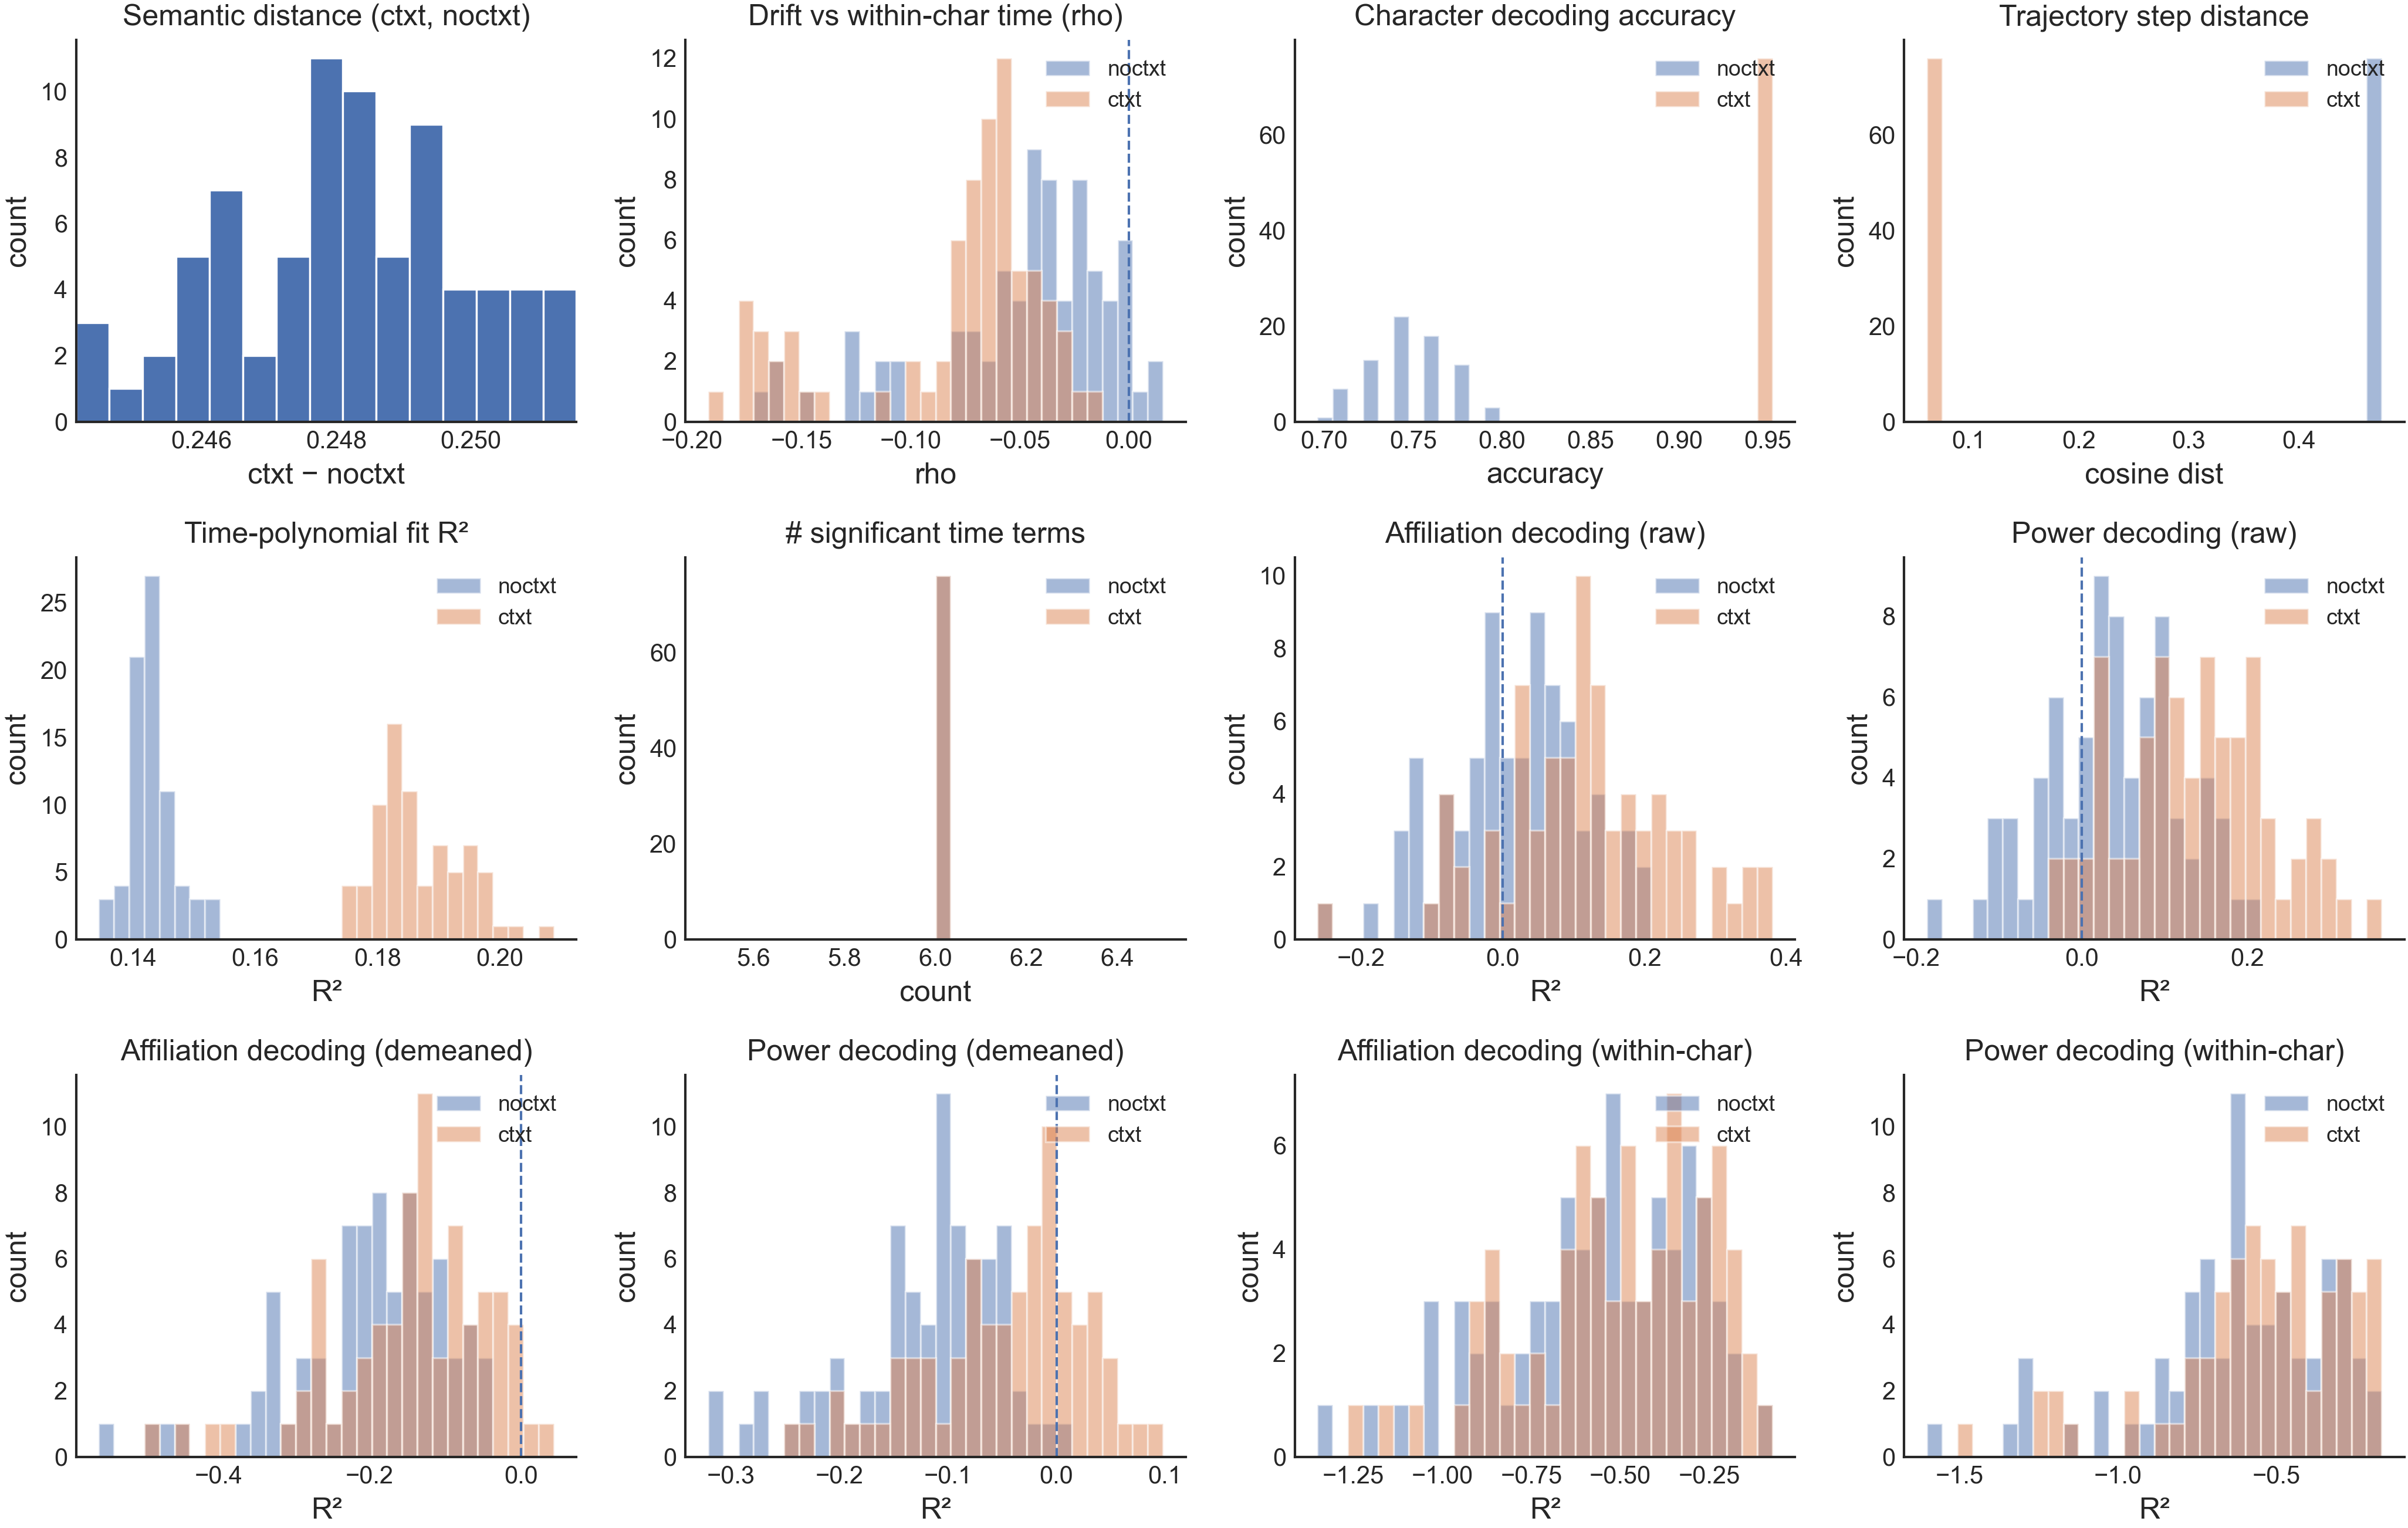

In [3]:
def plot_metric_grid_overlays(df, *, bins=30, ncols=4):
    panels = [
        ("single", "mean_ctxt_minus_noctxt_dist", "Semantic distance (ctxt, noctxt)", "ctxt − noctxt"),
        ("overlay", "drift_vs_time_rho_ctxt", "drift_vs_time_rho_noctxt", "Drift vs within-char time (rho)", "rho"),
        ("overlay", "char_decode_acc_ctxt", "char_decode_acc_noctxt", "Character decoding accuracy", "accuracy"),
        ("overlay", "traj_step_dist_ctxt", "traj_step_dist_noctxt", "Trajectory step distance", "cosine dist"),
        ("overlay", "timepoly_r2_ctxt", "timepoly_r2_noctxt", "Time-polynomial fit R²", "R²"),
        ("overlay", "timepoly_nsig_ctxt", "timepoly_nsig_noctxt", "# significant time terms", "count"),
        ("overlay", "r2_aff_ctxt", "r2_aff_noctxt", "Affiliation decoding (raw)", "R²"),
        ("overlay", "r2_pow_ctxt", "r2_pow_noctxt", "Power decoding (raw)", "R²"),
        ("overlay", "r2_aff_ctxt_dm", "r2_aff_noctxt_dm", "Affiliation decoding (demeaned)", "R²"),
        ("overlay", "r2_pow_ctxt_dm", "r2_pow_noctxt_dm", "Power decoding (demeaned)", "R²"),
        ("overlay", "r2_aff_ctxt_within", "r2_aff_noctxt_within", "Affiliation decoding (within-char)", "R²"),
        ("overlay", "r2_pow_ctxt_within", "r2_pow_noctxt_within", "Power decoding (within-char)", "R²"),
    ]

    # filter panels to those that exist
    keep = []
    for p in panels:
        if p[0] == "single":
            _, col, *_ = p
            if col in df.columns and np.issubdtype(df[col].dtype, np.number):
                keep.append(p)
        else:
            _, c_ctxt, c_noctxt, *_ = p
            if (c_ctxt in df.columns and c_noctxt in df.columns and
                np.issubdtype(df[c_ctxt].dtype, np.number) and
                np.issubdtype(df[c_noctxt].dtype, np.number)):
                keep.append(p)

    n = len(keep)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, p in zip(axes, keep):
        if p[0] == "single":
            _, col, title, xlabel = p
            x = df[col].to_numpy()
            x = x[np.isfinite(x)]

            # --- IMPORTANT: data-driven range + fewer bins for semantic shift
            if col == "mean_ctxt_minus_noctxt_dist":
                if len(x):
                    lo, hi = np.quantile(x, [0.01, 0.99])
                    pad = 0.05 * (hi - lo + 1e-12)
                    lo -= pad; hi += pad
                    ax.hist(x, bins=15, range=(lo, hi))
                    ax.set_xlim(lo, hi)
                else:
                    ax.hist(x, bins=15)

            else:
                ax.hist(x, bins=bins)

            ax.set_title(title)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("count")

        else:
            _, c_ctxt, c_noctxt, title, xlabel = p
            x_c = df[c_ctxt].to_numpy()
            x_n = df[c_noctxt].to_numpy()
            x_c = x_c[np.isfinite(x_c)]
            x_n = x_n[np.isfinite(x_n)]
            if len(x_c) == 0 or len(x_n) == 0:
                ax.axis("off")
                continue

            lo = min(x_c.min(), x_n.min())
            hi = max(x_c.max(), x_n.max())

            ax.hist(x_n, bins=bins, range=(lo, hi), alpha=0.5, label="noctxt")
            ax.hist(x_c, bins=bins, range=(lo, hi), alpha=0.5, label="ctxt")

            # draw zero line only when it is in range (prevents weird autoscaling)
            if lo <= 0 <= hi:
                ax.axvline(0, linestyle="--", linewidth=1)

            ax.set_title(title)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("count")
            ax.legend(frameon=False)

    for ax in axes[len(keep):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_metric_grid_overlays(metrics_df)


## uncertainty in semantic structure

In [4]:
def eigenspectrum_entropy(
    X: np.ndarray,
    *,
    center: bool = True,
    eps: float = 1e-12,
):
    """
    X: (T, D) embeddings (trials x features)

    Returns:
      evals: eigenvalues of covariance (sorted desc)
      p:     normalized eigenvalues (sum to 1)
      H:     Shannon entropy (nats)
      H_norm: H / log(k) where k = number of evals kept (0..1-ish)
      erank:  exp(H) (effective rank)
    """
    X = np.asarray(X, float)
    # drop trials with any NaNs
    good = np.isfinite(X).all(axis=1)
    X = X[good]
    T, D = X.shape
    if T < 2:
        return dict(evals=np.array([]), p=np.array([]), H=np.nan, H_norm=np.nan, erank=np.nan, T=T, D=D)

    if center:
        X = X - X.mean(axis=0, keepdims=True)

    # covariance eigenvalues via SVD for numerical stability:
    # If X = U S V^T, then cov = (X^T X)/(T-1) has eigenvalues (S^2)/(T-1)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    evals = (S * S) / max(T - 1, 1)

    # keep strictly positive spectrum (avoid tiny numerical negatives/zeros)
    evals = np.maximum(evals, 0.0)
    keep = evals > eps
    evals = evals[keep]
    if evals.size == 0:
        return dict(evals=np.array([]), p=np.array([]), H=0.0, H_norm=0.0, erank=1.0, T=T, D=D)

    p = evals / (evals.sum() + eps)

    H = float(-(p * np.log(p + eps)).sum())
    H_norm = float(H / (np.log(len(p)) + eps))
    erank = float(np.exp(H))

    return dict(evals=evals, p=p, H=H, H_norm=H_norm, erank=erank, T=T, D=D)

def compute_subject_spectrum_entropies(subject_data: dict, which=("embds_ctxt","embds_noctxt")):
    """
    subject_data[sub_id] is the dict returned by load_subject_data.

    Returns a tidy DataFrame with one row per subject x embedding type.
    """
    rows = []
    for sub_id, sd in subject_data.items():
        for key in which:
            if key not in sd or sd[key] is None:
                continue
            stats = eigenspectrum_entropy(sd[key], center=True)
            rows.append({
                "sub_id": sub_id,
                "embd_kind": key,
                "T": stats["T"],
                "D": stats["D"],
                "H": stats["H"],
                "H_norm": stats["H_norm"],
                "erank": stats["erank"],
                "k": len(stats["p"]),              # number of retained components
                "top1_frac": float(stats["p"][0]) if len(stats["p"]) else np.nan,  # optional diagnostic
            })
    return pd.DataFrame(rows)

entropy_df     = compute_subject_spectrum_entropies(subject_data).merge(data)
entropy_noctxt = entropy_df[entropy_df['embd_kind']=='embds_noctxt']
entropy_ctxt   = entropy_df[entropy_df['embd_kind']=='embds_ctxt']

|    | y   | x           |   dof |   rsq |   adj_rsq |     bic |     aic |   beta |    se |   95%_lb |   95%_ub |        t |     p |   p_left |   p_right |
|---:|:----|:------------|------:|------:|----------:|--------:|--------:|-------:|------:|---------:|---------:|---------:|------:|---------:|----------:|
|  0 | H   | Intercept   |    71 | 0.069 |     0.017 | -560.31 | -571.97 |  3.583 | 0.001 |    3.58  |    3.585 | 2506.13  | 0     |    1     |     0     |
|  1 | H   | dx[T.HC]    |    71 | 0.069 |     0.017 | -560.31 | -571.97 |  0     | 0.001 |   -0.002 |    0.003 |    0.276 | 0.784 |    0.608 |     0.392 |
|  2 | H   | sex[T.M]    |    71 | 0.069 |     0.017 | -560.31 | -571.97 | -0.001 | 0.001 |   -0.003 |    0.002 |   -0.388 | 0.7   |    0.35  |     0.65  |
|  3 | H   | ctq_score   |    71 | 0.069 |     0.017 | -560.31 | -571.97 |  0.001 | 0.001 |   -0     |    0.003 |    1.918 | 0.059 |    0.97  |     0.03  |
|  4 | H   | memory_mean |    71 | 0.069 |     0.017 | -560.31 | -571.97 |  0.001 | 0.001 |   -0.001 |    0.002 |    0.802 | 0.426 |    0.787 |     0.213 |

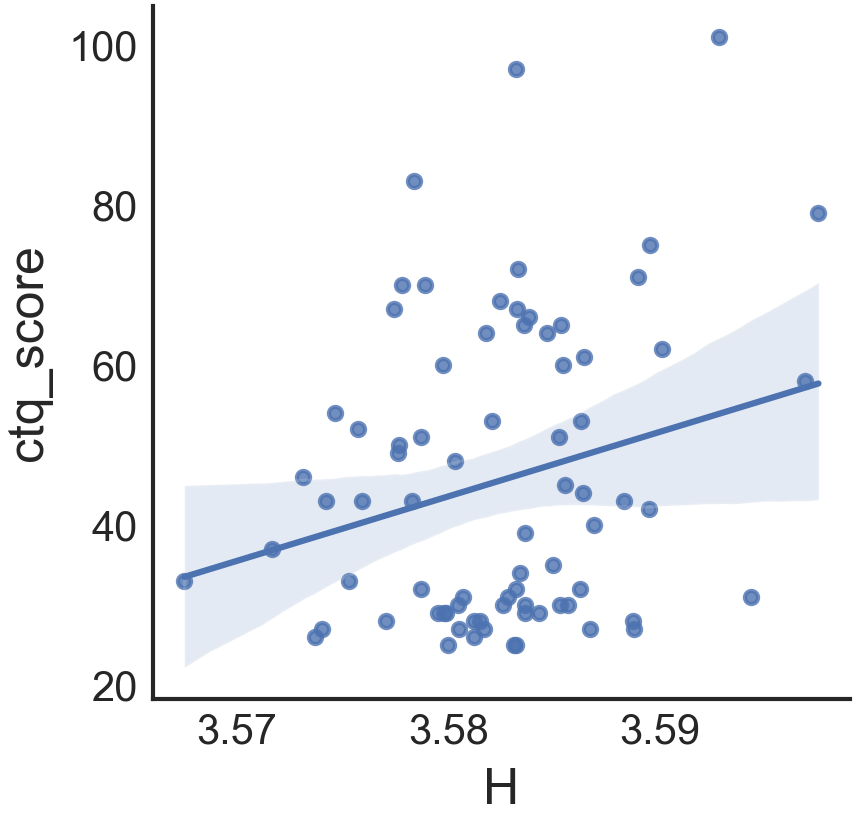

In [7]:
print_df(run_regression('H ~ dx + ctq_score + sex + memory_mean', data=entropy_noctxt))

fig, ax = plt.subplots(figsize=(3, 3))
sns.regplot(x='H', y='ctq_score', data=entropy_noctxt, scatter_kws={'s':10});

In [ ]:
def _unit_rows(X, eps=1e-12):
    X = np.asarray(X, float)
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(n, eps, None)

def embedding_character_metrics(char_embds, *, metric="cosine", eps=1e-12):
    """
    char_embds: list of arrays [E_c] where E_c is (T_c, D)

    Returns:
      embd_within_sim      : mean within-character similarity (cosine)
      embd_between_cent_sim: mean similarity between character centroids (cosine)
      embd_cdi             : (1-within)/(1-between) -- higher = less separable (overlap)
      embd_nn_cent_acc     : nearest-centroid classification accuracy (higher = more separable)
      embd_within_std      : std across characters of within similarity
    """
    # Filter empty
    char_embds = [np.asarray(E, float) for E in char_embds if E is not None and np.asarray(E).shape[0] > 0]
    C = len(char_embds)
    if C < 2:
        return dict(
            embd_within_sim=np.nan,
            embd_within_std=np.nan,
            embd_between_cent_sim=np.nan,
            embd_cdi=np.nan,
            embd_nn_cent_acc=np.nan,
        )

    # Within-character similarity (cosine)
    within_sims = []
    for E in char_embds:
        if E.shape[0] < 2:
            continue
        En = _unit_rows(E, eps=eps)
        # mean cosine similarity = 1 - mean cosine distance
        within_sims.append(float(1.0 - pdist(En, metric="cosine").mean()))
    embd_within_sim = float(np.nanmean(within_sims)) if len(within_sims) else np.nan
    embd_within_std = float(np.nanstd(within_sims)) if len(within_sims) else np.nan

    # Centroids and between-centroid similarity
    cents = []
    for E in char_embds:
        En = _unit_rows(E, eps=eps)
        c = En.mean(axis=0)
        c = c / max(np.linalg.norm(c), eps)
        cents.append(c)
    cents = np.vstack(cents)  # (C,D)

    # Pairwise cosine similarities between centroids
    between_cent_sim = float(1.0 - pdist(cents, metric="cosine").mean())

    # CDI analog (higher = more overlap / less separability)
    denom = max(1.0 - between_cent_sim, eps)
    embd_cdi = float((1.0 - embd_within_sim) / denom) if np.isfinite(embd_within_sim) else np.nan

    # Nearest-centroid classification accuracy (fast)
    # For each trial embedding, assign to closest centroid (cosine distance)
    total = 0
    correct = 0
    for k, E in enumerate(char_embds):
        if E.shape[0] < 1:
            continue
        En = _unit_rows(E, eps=eps)
        d = pairwise_distances(En, cents, metric="cosine")  # (T_k, C)
        pred = np.argmin(d, axis=1)
        total += len(pred)
        correct += int(np.sum(pred == k))
    embd_nn_cent_acc = float(correct / total) if total > 0 else np.nan

    return dict(
        embd_within_sim=embd_within_sim,
        embd_within_std=embd_within_std,
        embd_between_cent_sim=between_cent_sim,
        embd_cdi=embd_cdi,
        embd_nn_cent_acc=embd_nn_cent_acc,
    )

def organize_by_character(X, char_ids):
    """
    X: (T, ...) array
    char_ids: (T,) array of character ids (ints)
    Returns: list of arrays [X_char1, X_char2, ...] in sorted char_id order
    """
    char_ids = np.asarray(char_ids)
    uniq = np.array(sorted(pd.unique(char_ids)))
    return [np.asarray(X)[char_ids == c] for c in uniq]

def eigenspectrum_entropy(X, *, center=True, eps=1e-12):
    """
    X: (T, D) embeddings
    Computes entropy of covariance eigenvalues (via SVD).
    Returns dict with H_norm, erank, top1_frac, k.
    """
    X = np.asarray(X, float)
    good = np.isfinite(X).all(axis=1)
    X = X[good]
    T, D = X.shape
    if T < 2:
        return dict(H=np.nan, H_norm=np.nan, erank=np.nan, top1_frac=np.nan, k=0, T=T, D=D)

    if center:
        X = X - X.mean(axis=0, keepdims=True)

    # cov eigenvalues are S^2/(T-1)
    _, S, _ = np.linalg.svd(X, full_matrices=False)
    evals = (S * S) / max(T - 1, 1)
    evals = np.maximum(evals, 0.0)

    keep = evals > eps
    evals = evals[keep]
    if evals.size == 0:
        return dict(H=0.0, H_norm=0.0, erank=1.0, top1_frac=np.nan, k=0, T=T, D=D)

    p = evals / (evals.sum() + eps)
    H = float(-(p * np.log(p + eps)).sum())
    H_norm = float(H / (np.log(len(p)) + eps))
    erank = float(np.exp(H))
    top1_frac = float(p[0])

    return dict(H=H, H_norm=H_norm, erank=erank, top1_frac=top1_frac, k=len(p), T=T, D=D)

def location_variance(coords):
    coords = np.asarray(coords, float)
    mu = coords.mean(axis=0, keepdims=True)
    dif = coords - mu
    return float(np.nanmean(dif[:, 0]**2 + dif[:, 1]**2))

def calculate_occupied_bins(locations):
    # locations assumed already “binned” enough; keeps your original logic
    trajectory_bins = [tuple(np.asarray(p)) for p in np.asarray(locations)]
    return int(len(set(trajectory_bins)))

def calculate_tortuosity_index(locations):
    locations = np.asarray(locations, float)
    if locations.shape[0] < 2:
        return np.nan
    path_length = np.sum(np.linalg.norm(np.diff(locations, axis=0), axis=1))
    displacement = np.linalg.norm(locations[-1] - locations[0])
    return np.nan if displacement == 0 else float(path_length / displacement)

def discrete_curvature(X):
    P = np.asarray(X, float)
    if P.shape[0] < 3:
        return np.array([np.nan] * P.shape[0])
    a = np.linalg.norm(P[1:-1] - P[:-2], axis=1)
    b = np.linalg.norm(P[2:]   - P[1:-1], axis=1)
    c = np.linalg.norm(P[2:]   - P[:-2], axis=1)
    s = (a + b + c) / 2
    area = np.sqrt(np.clip(s*(s-a)*(s-b)*(s-c), 0, None))
    with np.errstate(divide="ignore", invalid="ignore"):
        kappa = 2 * area / (a*b*c)
    return kappa

def calc_within_behav_consistency_orig(all_char_decisions):
    """
    Your original definition (slightly simplified, same output).
    Returns mean across characters of average “consistency_r”.
    """
    def _calc_cum_mean(data, mask):
        cs = np.nancumsum(data, axis=0)
        cc = np.nancumsum(mask, axis=0)
        cc = np.where(cc == 0, np.nan, cc)
        return cs / cc

    char_scores = []
    for decisions in all_char_decisions:
        decisions = np.asarray(decisions, float)
        if decisions.size == 0:
            continue
        resp_mask = np.ones_like(decisions)

        n_trials, n_dims = decisions.shape
        con_decs = resp_mask * 1
        incon_decs = np.zeros_like(resp_mask)
        for d in range(n_dims):
            dim_mask = resp_mask[:, d] != 0
            dim_con = con_decs[dim_mask, d]
            incon_decs[dim_mask, d] = [n if (i % 2 == 0) else -n for i, n in enumerate(dim_con)]

        min_coords = _calc_cum_mean(incon_decs, resp_mask)
        max_coords = _calc_cum_mean(con_decs,   resp_mask)
        act_coords = _calc_cum_mean(decisions,  resp_mask)

        min_r = np.linalg.norm(min_coords, axis=1)
        max_r = np.linalg.norm(max_coords, axis=1)
        act_r = np.linalg.norm(act_coords, axis=1)

        diff = max_r - min_r
        diff = np.where(diff == 0, np.nan, diff)
        consistency_r = (act_r - min_r) / diff
        char_scores.append(np.nanmean(consistency_r))

    return float(np.nanmean(char_scores)) if len(char_scores) else np.nan

def calculate_mean_intra_character_dispersion(all_char_locations, all_char_choices=None):
    ds = []
    for i, locs in enumerate(all_char_locations):
        locs = np.asarray(locs, float)
        if locs.size == 0:
            continue
        if all_char_choices is not None:
            ch = np.asarray(all_char_choices[i], float)
            mask = np.any(ch != 0, axis=1)
            locs = locs[mask]
        if locs.shape[0] < 1:
            continue
        cen = locs.mean(axis=0)
        ds.append(np.mean(np.linalg.norm(locs - cen, axis=1)))
    return float(np.nanmean(ds)) if len(ds) else np.nan

def calculate_mean_inter_character_separation(all_char_locations, all_char_choices=None):
    cents = []
    for i, locs in enumerate(all_char_locations):
        locs = np.asarray(locs, float)
        if locs.size == 0:
            continue
        if all_char_choices is not None:
            ch = np.asarray(all_char_choices[i], float)
            mask = np.any(ch != 0, axis=1)
            locs = locs[mask]
        if locs.shape[0] < 1:
            continue
        cents.append(locs.mean(axis=0))
    if len(cents) < 2:
        return np.nan
    d = pairwise_distances(np.vstack(cents), metric="euclidean")
    iu = np.triu_indices_from(d, 1)
    return float(d[iu].mean())

# -------------------------
# Main: run over subject_data
# -------------------------

def compute_subject_semantic_behavior_scores(subject_data, *, use="ctxt"):
    rows = []

    for sub_id, sd in subject_data.items():
        if "behavior" not in sd or sd["behavior"] is None:
            continue

        behav = sd["behavior"]
        required = ["affil_decision", "power_decision", "affil_coord", "power_coord", "character_role_num"]
        if any(c not in behav.columns for c in required):
            continue

        choices   = behav[["affil_decision", "power_decision"]].to_numpy()
        locations = behav[["affil_coord", "power_coord"]].fillna(0).to_numpy()
        char_ids  = behav["character_role_num"].to_numpy()

        char_choices   = organize_by_character(choices,   char_ids)
        char_locations = organize_by_character(locations, char_ids)

        # --- behavioral measures ---
        tortuosity    = float(np.nanmean([calculate_tortuosity_index(loc) for loc in char_locations]))
        occupied_bins = calculate_occupied_bins(locations)
        loc_var       = float(np.nanmean([location_variance(loc) for loc in char_locations]))

        behav_curv      = float(np.nanmean(discrete_curvature(locations)))
        behav_wn        = calc_within_behav_consistency_orig(char_choices)
        behav_char_sep  = calculate_mean_inter_character_separation(char_locations, char_choices)
        behav_char_disp = calculate_mean_intra_character_dispersion(char_locations, char_choices)
        behav_cdi       = np.nan if (not np.isfinite(behav_char_sep) or behav_char_sep == 0) else behav_char_disp / behav_char_sep

        # --- choose embeddings ---
        embd_items = []
        if use in ("ctxt", "both") and sd.get("embds_ctxt") is not None:
            embd_items.append(("embds_ctxt", sd["embds_ctxt"]))
        if use in ("noctxt", "both") and sd.get("embds_noctxt") is not None:
            embd_items.append(("embds_noctxt", sd["embds_noctxt"]))

        for embd_kind, embds in embd_items:
            embds = np.asarray(embds, float)

            # entropy
            ent = eigenspectrum_entropy(embds, center=True)

            # overall mean pairwise cosine similarity
            if embds.shape[0] >= 2:
                Xn = _unit_rows(embds)
                embd_sim = float(1.0 - pdist(Xn, metric="cosine").mean())
            else:
                embd_sim = np.nan

            # --- NEW: character organization in embedding space ---
            char_embds = organize_by_character(embds, char_ids)
            embd_char = embedding_character_metrics(char_embds)

            rows.append({
                "sub_id": sub_id,
                "embd_kind": embd_kind,

                # global embedding geometry
                "embd_H_norm": ent["H_norm"],
                "embd_erank": ent["erank"],
                "embd_top1_frac": ent["top1_frac"],
                "embd_k": ent["k"],
                "embd_sim": embd_sim,

                # NEW: embedding character separability / overlap
                **embd_char,

                # behavior
                "tortuosity": tortuosity,
                "occupied_bins": occupied_bins,
                "loc_variance": loc_var,
                "behav_curv": behav_curv,
                "behav_within": behav_wn,
                "behav_char_sep": behav_char_sep,
                "behav_char_disp": behav_char_disp,
                "behav_cdi": behav_cdi,
            })

    return pd.DataFrame(rows)


score_df = compute_subject_semantic_behavior_scores(subject_data, use="both")
score_df = score_df.merge(data)

In [ ]:
def plot_corr_heatmap(corr, *, title="", vmin=-1, vmax=1, figsize=(9, 7), annot=True):
    C = corr.to_numpy()
    labels = list(corr.columns)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(C, vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r")

    # Optional: annotate cells with r values
    if annot:
        for i in range(C.shape[0]):
            for j in range(C.shape[1]):
                if np.isfinite(C[i, j]):
                    ax.text(j, i, f"{C[i, j]:.2f}", ha="center", va="center", fontsize=8)

    # Light gridlines for readability
    ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="k", linestyle="-", linewidth=0.3, alpha=0.15)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    return fig, ax

def make_corr_df(score_df, *, embd_kind="embds_ctxt"):
    df = score_df.copy()

    # restrict to one embedding type so rows are one-per-subject
    if "embd_kind" in df.columns:
        df = df[df["embd_kind"] == embd_kind].copy()

    # pick metrics to correlate
    metrics = [

        "ctq_score",
        
        # -----------------------------
        # semantic geometry (global)
        # -----------------------------
        "embd_H_norm",
        "embd_top1_frac",
        "embd_sim",

        # -----------------------------
        # semantic geometry (by character)
        # -----------------------------
        "embd_within_sim",          # higher = tighter within-character embedding clusters
        "embd_within_std",          # heterogeneity of within-character tightness
        "embd_between_cent_sim",    # higher = more overlap between character centroids
        "embd_cdi",                 # (1-within)/(1-between); higher = less separable
        "embd_nn_cent_acc",         # nearest-centroid accuracy; higher = more separable

        # -----------------------------
        # behavioral "consistency" family
        # -----------------------------
        "behav_cdi",
        "behav_char_disp",
        "behav_char_sep",
        "behav_within",

        # -----------------------------
        # others
        # -----------------------------
        "beh_dots_dist_zscore",
    ]

    # keep only metrics that exist
    metrics = [c for c in metrics if c in df.columns]

    # compute pairwise correlations with pairwise complete observations
    corr = df[metrics].corr(method="pearson", min_periods=10)

    return df, corr, metrics

df_noctxt, corr_noctxt, metrics_noctxt = make_corr_df(score_df, embd_kind="embds_noctxt")
plot_corr_heatmap(corr_noctxt, title="Correlation matrix")
plt.show()

<h1 align='center'> Semantics encode dimension </h1>

Just the local context of each choice (no relationship history)

Consistent with previous thing

In [ ]:
n_perm = 10
rng = np.random.default_rng(123)

results = []

for sub_id, sd in subject_data.items():
    X = sd['embds_noctxt'][sd['valid_dim_mask']]
    y = sd['dim_label'][sd['valid_dim_mask']]  # 1=affil, 2=power

    # ---------------- observed
    mean_acc, outer_accs, best_Cs = clf(X, y)

    # ---------------- null: shuffle labels
    null_accs = []
    for i in range(n_perm):
        y_perm = rng.permutation(y)
        mean_null, _, _ = clf(X, y_perm)
        null_accs.append(mean_null)

    null_accs = np.array(null_accs)

    # empirical p-value: fraction of null >= observed
    p_dim = (np.sum(null_accs >= mean_acc) + 1) / (n_perm + 1)

    results.append({
        'sub_id': sub_id,

        # observed
        'mean_acc': mean_acc,
        'outer_accs': outer_accs,
        'best_Cs': best_Cs,

        # null + p-value
        'null_mean_accs': null_accs.mean(),
        'p_dim': p_dim,
        'n_trials': len(y),
    })

dim_results = pd.DataFrame(results)


In [ ]:
plt.figure(figsize=(5, 4))
sns.histplot(dim_results['mean_acc'].to_numpy(), bins=8, kde=True)
sns.histplot(dim_results['null_mean_accs'].to_numpy(), bins=8, kde=True, color='grey', alpha=0.6)
plt.axvline(0.5, linestyle='--', linewidth=1)
plt.xlabel('Accuracy (affil vs power)')
plt.ylabel('Number of subjects')
plt.title('Subject-wise dimension decoding')
plt.tight_layout()
plt.show()

<h1 align='center'> Character embeddings mirror locations </h1>

try to recover trajectory-like similarities across characters, while controlling information about time

basically says: the way we model the behavior tracks the semantic content in the narrative

## Sanity check that the embeddings differentiate characters, and predict locations within character

In [ ]:
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from matplotlib.lines import Line2D

def permute_decisions_and_recompute_locs(decisions, char_ids, rng=None):
    """
    decisions : (T, 2) array with columns [affil_step, power_step] in {-1,0,+1}
    char_ids  : (T,) array of character labels

    Returns
    -------
    Y_perm : (T, 2) cumulative coords [affil_coord, power_coord] after within-character permutation
    """
    if rng is None:
        rng = np.random.default_rng()

    decisions = np.asarray(decisions)
    char_ids = np.asarray(char_ids)
    T = decisions.shape[0]
    assert decisions.shape == (T, 2), "decisions must be (T,2)"
    assert char_ids.shape[0] == T, "char_ids must align to decisions"

    # 1) permute rows of decisions within each character
    decisions_perm = np.zeros_like(decisions)
    unique_chars = np.unique(char_ids)

    for ch in unique_chars:
        idx = np.where(char_ids == ch)[0]
        perm_idx = rng.permutation(idx)
        decisions_perm[idx] = decisions[perm_idx]

    # 2) recompute cumulative coordinates within each character
    affil_steps = decisions_perm[:, 0]
    power_steps = decisions_perm[:, 1]

    affil_coord = np.zeros(T, dtype=float)
    power_coord = np.zeros(T, dtype=float)

    for ch in unique_chars:
        idx = np.where(char_ids == ch)[0]
        affil_coord[idx] = np.cumsum(affil_steps[idx])
        power_coord[idx] = np.cumsum(power_steps[idx])

    return np.column_stack([affil_coord, power_coord])

def permute_locs_between_characters(Y, char_ids, rng=None, require_equal_counts=False, derange=True):
    """
    Y       : (T,2) cumulative coords [affil_coord, power_coord]
    char_ids: (T,) character labels

    Returns
    -------
    Y_perm : (T,2) cumulative coords with *entire trajectories* swapped between characters.
             Preserves within-character temporal order by aligning by local index.

    Notes
    -----
    - If characters have unequal number of trials, you can:
        (a) set require_equal_counts=True to enforce equality, OR
        (b) leave it False and it will swap only if equal (otherwise raises).
      In practice, equal-count is rarely true; most analyses use the first null
      (within-character step permutation) as the main “history” null.
    """
    if rng is None:
        rng = np.random.default_rng()

    Y = np.asarray(Y)
    char_ids = np.asarray(char_ids)

    unique_chars = np.unique(char_ids)

    lengths = [np.sum(char_ids == ch) for ch in unique_chars]
    if len(set(lengths)) != 1:
        if require_equal_counts:
            raise ValueError("Unequal trials per character; cannot swap trajectories cleanly.")
        else:
            raise ValueError(
                "permute_locs_between_characters requires equal trials per character "
                "(or pre-balance / truncate per character)."
            )

    # permutation, optionally deranged (no one keeps their own)
    if derange and len(unique_chars) > 1:
        for _ in range(1000):
            perm = rng.permutation(unique_chars)
            if not np.any(perm == unique_chars):
                break
        else:
            perm = rng.permutation(unique_chars)  # fallback
    else:
        perm = rng.permutation(unique_chars)

    mapping = dict(zip(unique_chars, perm))

    Y_perm = np.zeros_like(Y)
    for dest_ch in unique_chars:
        src_ch = mapping[dest_ch]
        dest_idx = np.where(char_ids == dest_ch)[0]
        src_idx  = np.where(char_ids == src_ch)[0]
        if len(dest_idx) != len(src_idx):
            raise ValueError("Character lengths mismatch; cannot swap trajectories cleanly.")
        Y_perm[dest_idx] = Y[src_idx]

    return Y_perm

def compute_subject_mds2(subject_data, embd_key="embds", seed=0, metric=True):
    """
    Adds sd['mds2'] and sd['mds2_goodmask'] to each subject.
    Returns dict {sub_id: Z} for convenience.
    """
    out = {}
    for sid, sd in subject_data.items():
        X = np.asarray(sd[embd_key])
        good = np.isfinite(X).all(axis=1)
        Xg = X[good]

        D = cosine_distances(Xg)
        mds = MDS(
            n_components=2,
            metric=metric,
            dissimilarity="precomputed",
            random_state=seed,
            n_init=1,
            max_iter=300,
            normalized_stress="auto" if hasattr(MDS(), "normalized_stress") else "auto",
        )
        Z = mds.fit_transform(D)

        sd["mds2"] = Z
        sd["mds2_goodmask"] = good
        out[sid] = Z
    return out

def plot_subjectwise_mds_by_character_from_precomputed(
    subject_data,
    char_key="character_ids",
    n_per_row=7,
    marker_size=50,
    alpha=0.75,
    title="2D MDS of embeddings (cosine distances), color-coded by character",
):
    """
    Plot precomputed sd['mds2'] per subject, color-coded by character id.
    Requires:
      sd['mds2'] and sd['mds2_goodmask'] from compute_subject_mds2().
    """

    sub_ids = list(subject_data.keys())
    n_sub = len(sub_ids)
    n_rows = int(np.ceil(n_sub / n_per_row))

    # global palette
    all_chars = []
    for sid in sub_ids:
        y = np.asarray(subject_data[sid][char_key])
        gm = subject_data[sid].get("mds2_goodmask", np.isfinite(y))
        y = y[gm]
        all_chars.extend(y.tolist())
    all_chars = np.asarray(all_chars)
    global_chars = np.unique(all_chars[np.isfinite(all_chars)])
    K_global = len(global_chars)

    cmap = plt.get_cmap("tab20", max(1, K_global))
    char2color = {ch: cmap(i) for i, ch in enumerate(global_chars)}

    fig, axs = plt.subplots(
        n_rows, n_per_row,
        figsize=(3.1 * n_per_row, 3.1 * n_rows),
        squeeze=False
    )

    for i, sid in enumerate(sub_ids):
        r, c = divmod(i, n_per_row)
        ax = axs[r, c]

        Z = np.asarray(subject_data[sid]["mds2"])
        y = np.asarray(subject_data[sid][char_key])
        gm = subject_data[sid]["mds2_goodmask"]
        y = y[gm]

        # drop any remaining NaNs in y or Z
        good = np.isfinite(y) & np.isfinite(Z).all(axis=1)
        Z = Z[good]
        y = y[good]

        for ch in np.unique(y):
            mask = (y == ch)
            ax.scatter(
                Z[mask, 0], Z[mask, 1],
                s=marker_size,
                alpha=alpha,
                color=char2color.get(ch, "gray"),
                linewidths=0
            )

        ax.set_title(str(sid))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal", adjustable="box")

    for j in range(n_sub, n_rows * n_per_row):
        r, c = divmod(j, n_per_row)
        axs[r, c].set_axis_off()

    legend_elems = [
        Line2D([0], [0], marker='o', color='w',
               label=str(ch), markerfacecolor=char2color[ch],
               markersize=6)
        for ch in global_chars
    ]
    fig.legend(
        handles=legend_elems,
        loc="upper center",
        ncol=min(10, max(1, len(legend_elems))),
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )

    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

#----------- run some regressions

def _r2_univariate(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

def _r2_joint(Z, Zhat):
    ss_res = np.sum((Z - Zhat) ** 2)
    ss_tot = np.sum((Z - Z.mean(axis=0, keepdims=True)) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

def cv_encode_social_to_mds2(
    Z, Y,
    n_splits=5,
    seed=0,
    alpha=1.0,
):
    """
    Predict 2D MDS coords Z from social coords Y = [affil_coord, power_coord]
    using cross-validated Ridge regression.

    Returns dict with r2_dim1, r2_dim2, r2_joint.
    """
    Z = np.asarray(Z, float)
    Y = np.asarray(Y, float)
    assert Z.shape[0] == Y.shape[0], "Z and Y must align"

    good = np.isfinite(Z).all(axis=1) & np.isfinite(Y).all(axis=1)
    Zg = Z[good]
    Yg = Y[good]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    Zhat = np.full_like(Zg, np.nan)

    for tr, te in kf.split(Yg):
        sc = StandardScaler()
        Xtr = sc.fit_transform(Yg[tr])
        Xte = sc.transform(Yg[te])

        model = Ridge(alpha=alpha, fit_intercept=True, random_state=seed)
        model.fit(Xtr, Zg[tr])
        Zhat[te] = model.predict(Xte)

    return {
        "r2_dim1": float(_r2_univariate(Zg[:, 0], Zhat[:, 0])),
        "r2_dim2": float(_r2_univariate(Zg[:, 1], Zhat[:, 1])),
        "r2_joint": float(_r2_joint(Zg, Zhat)),
        "n_used": int(Zg.shape[0]),
    }

def perm_test_with_decision_nulls(
    Z, decisions, char_ids,
    n_perm=200,
    seed=0,
    n_splits=5,
    alpha=1.0,
    null_type="within_char_steps",  # or "swap_trajectories"
    require_equal_counts=False,
):
    """
    Real: regress Z ~ Y where Y are cumulative coords from *true* decisions.
    Null: recompute Y under your permutation scheme, then regress.

    decisions : (T,2) steps in {-1,0,+1} for [affil_step, power_step]
    char_ids  : (T,)
    """
    rng = np.random.default_rng(seed)
    decisions = np.asarray(decisions)
    char_ids = np.asarray(char_ids)

    # real Y from true decisions
    Y_real = np.zeros_like(decisions, dtype=float)
    for ch in np.unique(char_ids):
        idx = np.where(char_ids == ch)[0]
        Y_real[idx, 0] = np.cumsum(decisions[idx, 0])
        Y_real[idx, 1] = np.cumsum(decisions[idx, 1])

    real = cv_encode_social_to_mds2(Z, Y_real, n_splits=n_splits, seed=seed, alpha=alpha)
    real_r2 = real["r2_joint"]

    null = np.empty(n_perm, float)

    for i in range(n_perm):
        if null_type == "within_char_steps":
            Yp = permute_decisions_and_recompute_locs(decisions, char_ids, rng=rng)

        elif null_type == "swap_trajectories":
            # first compute Y_real (already computed), then swap full trajectories between chars
            Yp = permute_locs_between_characters(
                Y_real, char_ids, rng=rng,
                require_equal_counts=require_equal_counts,
                derange=True
            )
        else:
            raise ValueError("null_type must be 'within_char_steps' or 'swap_trajectories'")

        outp = cv_encode_social_to_mds2(Z, Yp, n_splits=n_splits, seed=seed, alpha=alpha)
        null[i] = outp["r2_joint"]

    p = float((1.0 + np.sum(null >= real_r2)) / (n_perm + 1.0))
    return real, null, p

def z_from_null(real, null, eps=1e-12):
    null = np.asarray(null, float)
    return float((real - null.mean()) / (null.std(ddof=1) + eps))

# Precompute MDS once
compute_subject_mds2(subject_data, embd_key="embds", seed=0, metric=True)

n_perm   = 50
seed     = 0
n_splits = 5
alpha    = 1.0
prepared = {}
for sub_id, sd in subject_data.items():
    Z  = np.asarray(sd["mds2"])
    y  = np.asarray(sd["character_ids"])
    gm = np.asarray(sd["mds2_goodmask"])

    decisions = np.asarray(sd["decisions"])[gm]
    char_ids  = y[gm]

    good = (
        np.isfinite(decisions).all(axis=1)
        & np.isfinite(char_ids)
        & np.isfinite(Z).all(axis=1)
    )
    prepared[sub_id] = {
        "Z": Z[good],
        "decisions": decisions[good],
        "char_ids": char_ids[good],
        "n_used": int(np.sum(good)),
    }

# within-character permute steps + recompute cum coords
rows = []
for sub_id, d in prepared.items():
    real, null, p = perm_test_with_decision_nulls(
        Z=d["Z"],
        decisions=d["decisions"],
        char_ids=d["char_ids"],
        n_perm=n_perm,
        seed=seed,
        n_splits=n_splits,
        alpha=alpha,
        null_type="within_char_steps",
        require_equal_counts=False,
    )
    rows.append({
        "sub_id": sub_id,
        "null_type": "within_char_steps",
        "r2_joint": real["r2_joint"],
        "r2_dim1": real["r2_dim1"],
        "r2_dim2": real["r2_dim2"],
        "n_used": real["n_used"],
        "p_perm": p,
        "null_mean": float(null.mean()),
        "null_std": float(null.std(ddof=1)),
        "null": null,
        "z_sub": z_from_null(real["r2_joint"], null),
    })

results_within = pd.DataFrame(rows)
t, p = scipy.stats.ttest_1samp(results_within["z_sub"], popmean=0)

plt.figure(figsize=(6, 4))
plt.hist(results_within["z_sub"], bins=15, alpha=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Z-score of CV R² vs. null")
plt.ylabel("Number of subjects")
plt.title(f"Z-scores across subjects (null = within_char_steps, n={len(results_within)})")
plt.text(
    0.95, 0.95,
    f"One-sample t-test vs. 0:\nt={t:.2f}, p={p:.3f}",
    horizontalalignment='right',
    verticalalignment='top',
    transform=plt.gca().transAxes,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
)
plt.tight_layout()
plt.show()

## comparing embeddings, behavior and subjective placements
theres some dof here with embeddings and behavior, given multiple values per subject; for now just use average...

In [ ]:
def rsa_one_subject(
    sd,
    data,
    sub_id,
    characters,
    id_offset=1,
):
    """
    Compute Kendall τ RSA values for one subject:
      emb vs beh
      emb vs dots
      beh vs dots
    """

    D_emb, D_beh, D_dots = character_distance_matrices_one_subject(
        sd=sd,
        data=data,
        sub_id=sub_id,
        characters=characters,
        id_offset=id_offset,
    )

    v_emb  = flatten_upper_tri(D_emb)
    v_beh  = flatten_upper_tri(D_beh)
    v_dots = flatten_upper_tri(D_dots)

    return {
        "sub_id": sub_id,
        "tau_emb_beh":   scipy.stats.kendalltau(v_emb,  v_beh)[0],
        "tau_emb_dots":  scipy.stats.kendalltau(v_emb,  v_dots)[0],
        "tau_beh_dots": scipy.stats.kendalltau(v_beh,  v_dots)[0],
    }

def rsa_all_subjects(
    subject_ids,
    data,
    characters,
    incl_neutral=False,
    id_offset=1,
):
    rows = []

    for sub_id in subject_ids:
        sd = load_subject_semantic_data(sub_id, incl_neutral=incl_neutral)

        out = rsa_one_subject(
            sd=sd,
            data=data,
            sub_id=sub_id,
            characters=characters,
            id_offset=id_offset,
        )
        rows.append(out)

    return pd.DataFrame(rows)

characters = ['first', 'second', 'assistant', 'powerful', 'boss']

rsa_df = rsa_all_subjects(
    subject_ids=incl_subs,
    data=data,
    characters=characters,
    incl_neutral=False,
    id_offset=1,
)

tests = {
    "Embeddings ↔ Behavior":  rsa_df["tau_emb_beh"],
    "Embeddings ↔ Dots":      rsa_df["tau_emb_dots"],
    "Behavior ↔ Dots":        rsa_df["tau_beh_dots"],
}

for name, vals in tests.items():
    stat, p = scipy.stats.wilcoxon(vals, alternative="greater")
    print(f"{name}: Wilcoxon W={stat:.2f}, p={p:.4g}, median τ={np.nanmedian(vals):.3f}")

def plot_rsa_distributions(rsa_df):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    pairs = [
        ("tau_emb_beh",  "Embeddings ↔ Behavior"),
        ("tau_emb_dots", "Embeddings ↔ Dots"),
        ("tau_beh_dots", "Behavior ↔ Dots"),
    ]

    for ax, (col, title) in zip(axs, pairs):
        vals = rsa_df[col].dropna()

        sns.histplot(vals, bins=10, kde=True, ax=ax)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(title)
        ax.set_xlabel("Kendall’s τ")
        ax.set_ylabel("Subjects")

        stat, p = wilcoxon_right_tailed(vals)
        ax.text(
            0.02, 0.95,
            f"Wilcoxon p = {p:.3g}\nmedian τ = {np.median(vals):.2f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
        )
        # add a vertical line for mean
        ax.axvline(np.median(vals), color="red", linewidth=1)

    plt.tight_layout()
    plt.show()

plot_rsa_distributions(rsa_df)

In [ ]:
def _stable_char_palette(num_chars, palette="husl"):
    """Stable palette across plots (RGBA tuples)."""
    return sns.color_palette(palette, num_chars)

def _axis_social_space(ax, lim=6):
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Affiliation")
    ax.set_ylabel("Power")

def make_char_color_maps(character_roles, palette="husl", id_offset=1):
    """
    Deterministic mapping from:
      - char_id   -> color   (char_id uses 1-based coding: 1->first, 2->second, ...)
      - char_name -> color
    """
    cols = _stable_char_palette(len(character_roles), palette=palette)
    id2color = {i + id_offset: cols[i] for i in range(len(character_roles))}
    name2color = {name: cols[i] for i, name in enumerate(character_roles)}
    return id2color, name2color

def _char_id_to_name_map(character_roles, id_offset=1):
    """Map 1-based numeric ids to names: 1->first, 2->second, ..."""
    return {i + id_offset: name for i, name in enumerate(character_roles)}

def plot_embds(
    sd,
    character_roles,  # ['first','second','assistant','powerful','boss']
    embd_key="embds",
    char_key="character_ids",
    seed=0,
    metric=True,
    s=30,
    alpha=0.70,
    palette="husl",
    ax=None,
    id_offset=1,      # IMPORTANT: 1-based coding
):
    X = np.asarray(sd[embd_key])
    y = np.asarray(sd[char_key])

    good = np.isfinite(X).all(axis=1) & np.isfinite(y)
    Xg = X[good]
    yg = y[good].astype(int)

    D = cosine_distances(Xg)
    mds = MDS(
        n_components=2,
        metric=metric,
        dissimilarity="precomputed",
        random_state=seed,
        n_init=1,
        max_iter=300,
        normalized_stress="auto" if hasattr(MDS(), "normalized_stress") else "auto",
    )
    Z = mds.fit_transform(D)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    id2name = _char_id_to_name_map(character_roles, id_offset=id_offset)
    id2color, _ = make_char_color_maps(character_roles, palette=palette, id_offset=id_offset)

    # enforce fixed ordering by *character_roles*, but in 1-based id space
    for ch in range(id_offset, id_offset + len(character_roles)):
        m = (yg == ch)
        if not np.any(m):
            continue
        ax.scatter(
            Z[m, 0], Z[m, 1],
            s=s, alpha=alpha,
            color=id2color.get(ch, "gray"),
            linewidths=0,
            label=id2name.get(ch, str(ch)),
        )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=False, fontsize=9, loc="best")
    ax.set_title("MDS embeddings ")
    return ax

def plot_behav(
    sd,
    character_roles,  # ['first','second','assistant','powerful','boss']
    char_key="character_ids",
    affil_key="affil_dir",
    power_key="power_dir",
    lim=6,
    lw=1.2,
    end_s=55,
    alpha_line=0.95,
    palette="husl",
    ax=None,
    id_offset=1,      # IMPORTANT: 1-based coding
):
    char_ids = np.asarray(sd[char_key]).astype(int)
    aff = np.asarray(sd[affil_key], dtype=float)
    pwr = np.asarray(sd[power_key], dtype=float)

    aff_step = np.nan_to_num(aff, nan=0.0)
    pwr_step = np.nan_to_num(pwr, nan=0.0)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    _axis_social_space(ax, lim=lim)

    id2name = _char_id_to_name_map(character_roles, id_offset=id_offset)
    id2color, _ = make_char_color_maps(character_roles, palette=palette, id_offset=id_offset)

    for ch in range(id_offset, id_offset + len(character_roles)):
        m = (char_ids == ch)
        if m.sum() == 0:
            continue

        x = np.cumsum(aff_step[m])
        y = np.cumsum(pwr_step[m])

        col = id2color.get(ch, "gray")
        ax.plot(x, y, color=col, linewidth=lw, alpha=alpha_line, label=id2name.get(ch, str(ch)))
        ax.scatter(x[-1], y[-1], color=col, s=end_s, zorder=3)

    ax.legend(frameon=False, fontsize=9, loc="best")
    ax.set_title("Behavior trajectories")
    return ax

def _get_subject_row(df: pd.DataFrame, sub_id, sub_col_candidates=("sub_id", "subject", "sub")) -> pd.Series:
    sub_col = next((c for c in sub_col_candidates if c in df.columns), None)
    if sub_col is None:
        raise ValueError(f"Could not find a subject id column in df. Tried {sub_col_candidates}.")
    rows = df.loc[df[sub_col].astype(str) == str(sub_id)]
    if len(rows) == 0:
        raise ValueError(f"No row found for sub_id={sub_id} in column '{sub_col}'.")
    if len(rows) > 1:
        print(f"Warning: found {len(rows)} rows for sub_id={sub_id} in '{sub_col}'. Using the first.")
    return rows.iloc[0]

def plot_subj(
    df: pd.DataFrame,
    sub_id,
    characters,                     # ['first','second','assistant','powerful','boss']
    lim=1,
    s=70,
    palette="husl",
    ax=None,
):
    subj_row = _get_subject_row(df, sub_id)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Affiliation")
    ax.set_ylabel("Power")

    # deterministic colors by *character name order* (same order as embeddings/behavior IDs)
    _, name2color = make_char_color_maps(characters, palette=palette)

    for char in characters:
        a_col = f"dots_affil_{char}"
        p_col = f"dots_power_{char}"
        if (a_col not in df.columns) or (p_col not in df.columns):
            continue

        x = subj_row[a_col]
        y = subj_row[p_col]
        if np.isfinite(x) and np.isfinite(y):
            ax.scatter(x, y, s=s, color=name2color[char], linewidths=0, label=char)

    ax.legend(frameon=False, fontsize=9, loc="best")
    ax.set_title("Subjective placements")
    return ax

characters = ['first', 'second', 'assistant', 'powerful', 'boss']
for sub_id in incl_subs[:10]:
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    sd = load_subject_semantic_data(sub_id, incl_neutral=False)
    plot_embds(sd, characters, ax=axs[0])
    plot_behav(sd, characters, ax=axs[1])
    plot_subj(data, sub_id, characters, ax=axs[2])

    plt.tight_layout()
    plt.show()


<h1 align='center'>Building a simple map from semantic embeddings to locations </h1>

## Linear map from embeddings to locations: relationship context helps 
linear mapping from embeddings → social space: does geometry of the predicted social locations matches the behavioral geometry better than a history-destroying null?

the null breaks history, but preserves:
- character identity
- choices
- specific events
- temporal smootheness
- overall trajectory scale and length
- total amount of affiliation/power change


right not we show:
- predicts trial-wise location (better than nulls)
- it preserves geometry
- memory helps (context embds > no context)

to do: 
- test how much history matters: embed different numbers of previous interactions (right now just all versus none)
- test whether current and last choice are alone sufficient
- do the shuffled character control
- run analyses that control for subject-level task features

In [ ]:
# Helpers: safe correlation + CV prediction + alpha selection

def mean_dimwise_corr(Y, Yhat):
    Y = np.asarray(Y); Yhat = np.asarray(Yhat)
    return np.nanmean([pearsonr(Y[:, d], Yhat[:, d])[0] for d in range(Y.shape[1])])

def cv_predict_ridge(X, Y, alphas, outer_splits=5, inner_splits=4):
    
    outer = KFold(n_splits=min(outer_splits, len(X)), shuffle=False)
    Yhat = np.zeros_like(Y, dtype=float)

    for tr, te in outer.split(X):
        # inner selection on training only
        alpha_best, _ = select_alpha_by_cv_corr(X[tr], Y[tr], alphas=alphas, n_splits=inner_splits)
        W, b, _ = fit_ridge_subspace(X[tr], Y[tr], alpha=alpha_best)
        Yhat[te] = project_embeddings(X[te], W, b)

    return Yhat

def select_alpha_by_cv_corr(X, Y, alphas=(0.1, 1.0, 10.0, 100.0), n_splits=5):
    """
    Choose alpha using CV on (X,Y) and scoring by mean dim-wise Pearson r.
    Uses a simple KFold inner CV (no nested call to cv_predict_ridge).
    """
    X = np.asarray(X); Y = np.asarray(Y)
    n = X.shape[0]
    n_splits_eff = min(n_splits, n)
    if n_splits_eff < 2:
        # fall back to middle alpha if we can't CV
        a0 = alphas[len(alphas) // 2]
        return a0, {a: np.nan for a in alphas}

    kf = KFold(n_splits=n_splits_eff, shuffle=False)
    scores = {}

    for a in alphas:
        Yhat = np.zeros_like(Y, dtype=float)
        for tr, te in kf.split(X):
            W, b, _ = fit_ridge_subspace(X[tr], Y[tr], alpha=a)
            Yhat[te] = project_embeddings(X[te], W, b)
        scores[a] = mean_dimwise_corr(Y, Yhat)

    alpha_best = max(scores, key=lambda a: (-np.inf if np.isnan(scores[a]) else scores[a]))
    return alpha_best, scores

def z_against_null(real, null, eps=1e-12):
    null = np.asarray(null, float)
    return (real - null.mean()) / (null.std(ddof=1) + eps)

def p_perm_greater(real, null):
    null = np.asarray(null, float)
    return float((1.0 + np.sum(null >= real)) / (len(null) + 1.0))

def p_perm_less(real, null):
    null = np.asarray(null, float)
    return float((1.0 + np.sum(null <= real)) / (len(null) + 1.0))

# Ridge probe + geometry

def fit_ridge_subspace(X, Y, alpha=10.0):
    """
    Fit Y ≈ XW + b with ridge.
    Returns W, b in original embedding space.
    """
    X = np.asarray(X)
    Y = np.asarray(Y)

    good = np.isfinite(X).all(1) & np.isfinite(Y).all(1)
    Xg = X[good]
    Yg = Y[good]

    sc = StandardScaler()
    Xz = sc.fit_transform(Xg)

    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(Xz, Yg)

    Wz = model.coef_.T
    W = Wz / sc.scale_[:, None]
    b = model.intercept_ - (sc.mean_ / sc.scale_) @ Wz

    return W, b, good

def project_embeddings(X, W, b):
    return np.asarray(X) @ W + b

def rsa_geometry(Y_true, Y_pred):
    """
    Kendall tau between distance matrices.
    """
    Y_true = np.asarray(Y_true); Y_pred = np.asarray(Y_pred)
    if Y_true.shape[0] < 3:
        return np.nan
    D_true = np.linalg.norm(Y_true[:, None] - Y_true[None], axis=-1)
    D_pred = np.linalg.norm(Y_pred[:, None] - Y_pred[None], axis=-1)
    iu = np.triu_indices_from(D_true, k=1)
    return kendalltau(D_true[iu], D_pred[iu]).correlation

def r2_joint(Y, Yhat, eps=1e-12):
    ss_res = np.sum((Y - Yhat) ** 2)
    ss_tot = np.sum((Y - Y.mean(axis=0, keepdims=True)) ** 2)
    return 1.0 - ss_res / (ss_tot + eps)

def cv_predict_per_character_mean(Y, char_ids, n_splits=5):
    """
    Baseline predictor: for each fold, predict each test trial's (affil,power)
    as the TRAINING-FOLD mean location for that character.

    Returns:
        Yhat_base: (T,2) array aligned to trials
    """
    Y = np.asarray(Y, float)
    char_ids = np.asarray(char_ids)
    n = len(char_ids)

    n_splits_eff = min(n_splits, n)
    if n_splits_eff < 2:
        return np.full_like(Y, np.nan, dtype=float)

    kf = KFold(n_splits=n_splits_eff, shuffle=False)
    Yhat = np.zeros_like(Y, dtype=float)

    global_mean = np.nanmean(Y, axis=0)

    for tr, te in kf.split(np.arange(n)):
        # compute character means on TRAIN only
        means = {}
        for ch in np.unique(char_ids[tr]):
            idx = tr[char_ids[tr] == ch]
            means[int(ch)] = np.nanmean(Y[idx], axis=0)

        # predict on TEST
        for i in te:
            ch = int(char_ids[i])
            Yhat[i] = means.get(ch, global_mean)  # fallback if unseen char in train

    return Yhat

def analyze_subject_ridge(
    sd,
    emb_key="embds_ctxt",          # <-- NEW (default preserves old behavior)
    alphas=(0.1, 1.0, 10.0, 100.0),
    n_splits=5,
    n_perm=30,
    seed=0,
):
    rng = np.random.default_rng(seed)

    X         = sd[emb_key]        # <-- CHANGED (was sd["embds_ctxt"])
    char_ids  = sd["character_ids"]
    decisions = sd["decisions"]

    Y_true = compute_social_locations(char_ids, decisions)

    # choose alpha by CV R² on real data
    kf = KFold(n_splits=min(n_splits, len(X)), shuffle=False)
    r2_by_alpha = {}
    for a in alphas:
        Yhat_cv = np.zeros_like(Y_true)
        for tr, te in kf.split(X):
            W, b, _ = fit_ridge_subspace(X[tr], Y_true[tr], alpha=a)
            Yhat_cv[te] = project_embeddings(X[te], W, b)
        r2_by_alpha[a] = r2_joint(Y_true, Yhat_cv)

    alpha_best = max(r2_by_alpha, key=r2_by_alpha.get)

    # out-of-fold predictions with best alpha
    Yhat = np.zeros_like(Y_true)
    for tr, te in kf.split(X):
        W, b, _ = fit_ridge_subspace(X[tr], Y_true[tr], alpha=alpha_best)
        Yhat[te] = project_embeddings(X[te], W, b)

    r2_real  = r2_joint(Y_true, Yhat)
    rsa_real = rsa_geometry(Y_true, Yhat)

    # baseline comparison: per-character mean (CV)
    Yhat_base = cv_predict_per_character_mean(Y_true, char_ids, n_splits=n_splits)
    r2_base   = r2_joint(Y_true, Yhat_base)
    rsa_base  = rsa_geometry(Y_true, Yhat_base)
    delta_r2  = r2_real  - r2_base
    delta_rsa = rsa_real - rsa_base

    # -------- axis geometry on FULL fit (readout vectors)
    W_full, b_full, _ = fit_ridge_subspace(X, Y_true, alpha=alpha_best)
    axis_corr_real  = 1 - cosine(W_full[:, 0], W_full[:, 1])
    axis_angle_real = np.degrees(np.arccos(np.clip(axis_corr_real, -1.0, 1.0)))

    # prediction null: refit on shuffled-choice trajectories
    r2_null = np.zeros(n_perm)
    axis_corr_null  = np.zeros(n_perm)
    axis_angle_null = np.zeros(n_perm)

    for i in range(n_perm):
        Yp = permute_decisions_and_recompute_locs(decisions, char_ids, rng)

        Yhat_p = np.zeros_like(Yp)
        for tr, te in kf.split(X):
            Wp, bp, _ = fit_ridge_subspace(X[tr], Yp[tr], alpha=alpha_best)
            Yhat_p[te] = project_embeddings(X[te], Wp, bp)
        r2_null[i] = r2_joint(Yp, Yhat_p)

        Wp_full, _, _ = fit_ridge_subspace(X, Yp, alpha=alpha_best)
        corr_p = 1 - cosine(Wp_full[:, 0], Wp_full[:, 1])
        axis_corr_null[i]  = corr_p
        axis_angle_null[i] = np.degrees(np.arccos(np.clip(corr_p, -1.0, 1.0)))

    # geometry null: permute behavioral trajectories only (keep extracted Yhat fixed)
    rsa_null = np.zeros(n_perm)
    for i in range(n_perm):
        Yp = permute_decisions_and_recompute_locs(decisions, char_ids, rng)
        rsa_null[i] = rsa_geometry(Yp, Yhat)

    return {
        "emb_key": emb_key,  # <-- NEW (for bookkeeping)

        # baseline metrics
        "r2_base": r2_base,
        "rsa_base": rsa_base,
        "delta_r2": delta_r2,
        "delta_rsa": delta_rsa,
        "Y_hat_base": Yhat_base,

        # main metrics
        "alpha_best": alpha_best,
        "r2_real": r2_real,
        "r2_null": r2_null,
        "rsa_real": rsa_real,
        "rsa_null": rsa_null,

        # axis diagnostics
        "axis_corr_real": float(axis_corr_real),
        "axis_angle_real": float(axis_angle_real),
        "axis_corr_null": axis_corr_null,
        "axis_angle_null": axis_angle_null,

        "Y_true": Y_true,
        "Y_hat": Yhat,
    }

def run_group_ridge(subject_data, n_perm=30, seed=0, n_splits=5, **kwargs):
    results = {}
    for sub_id, sd in subject_data.items():
        try:
            r_ctxt   = analyze_subject_ridge(
                sd, emb_key="embds_ctxt",
                n_perm=n_perm, seed=seed, n_splits=n_splits, **kwargs
            )
            r_noctxt = analyze_subject_ridge(
                sd, emb_key="embds_noctxt",
                n_perm=n_perm, seed=seed, n_splits=n_splits, **kwargs
            )
            results[sub_id] = {"ctxt": r_ctxt, "noctxt": r_noctxt}
        except Exception as e:
            print(f"Skipping {sub_id}: {e}")
    return results

def summarize_group_results(results, eps=1e-12):
    rows = []
    for sub_id, rr in results.items():
        rc = rr["ctxt"]
        rn = rr["noctxt"]

        rows.append({
            "sub_id": sub_id,

            # ----------------------------
            # Prediction (ctxt)
            # ----------------------------
            "r2_base_ctxt":  rc["r2_base"],
            "delta_r2_ctxt": rc["delta_r2"],
            "r2_ctxt":       rc["r2_real"],
            "r2_z_ctxt":     float(z_against_null(rc["r2_real"],  rc["r2_null"],  eps=eps)),

            # ----------------------------
            # Prediction (noctxt)
            # ----------------------------
            "r2_base_noctxt":  rn["r2_base"],
            "delta_r2_noctxt": rn["delta_r2"],
            "r2_noctxt":       rn["r2_real"],
            "r2_z_noctxt":     float(z_against_null(rn["r2_real"], rn["r2_null"], eps=eps)),

            # ctxt benefit (memory)
            "r2_ctxt_minus_noctxt": rc["r2_real"] - rn["r2_real"],
            "delta_r2_ctxt_minus_noctxt": rc["delta_r2"] - rn["delta_r2"],

            # ----------------------------
            # Geometry (ctxt)
            # ----------------------------
            "rsa_base_ctxt":  rc["rsa_base"],
            "delta_rsa_ctxt": rc["delta_rsa"],
            "rsa_ctxt":       rc["rsa_real"],
            "rsa_z_ctxt":     float(z_against_null(rc["rsa_real"],  rc["rsa_null"],  eps=eps)),

            # ----------------------------
            # Geometry (noctxt)
            # ----------------------------
            "rsa_base_noctxt":  rn["rsa_base"],
            "delta_rsa_noctxt": rn["delta_rsa"],
            "rsa_noctxt":       rn["rsa_real"],
            "rsa_z_noctxt":     float(z_against_null(rn["rsa_real"], rn["rsa_null"], eps=eps)),

            # ctxt benefit (memory)
            "rsa_ctxt_minus_noctxt": rc["rsa_real"] - rn["rsa_real"],
            "delta_rsa_ctxt_minus_noctxt": rc["delta_rsa"] - rn["delta_rsa"],

            # Axis diagnostics (only really meaningful for ctxt; but you can inspect both)
            "axis_angle_ctxt":   float(rc["axis_angle_real"]),
            "axis_angle_noctxt": float(rn["axis_angle_real"]),
        })
    return pd.DataFrame(rows)

ridge_results = run_group_ridge(subject_data, n_perm=30, seed=0)
ridge_df      = summarize_group_results(ridge_results)

In [ ]:
#-------------------- stats 

t_dr2_ctxt, p_dr2_ctxt   = ttest_1samp(ridge_df["delta_r2_ctxt"], popmean=0, alternative="greater")      # ctxt > char-mean
t_r2z_ctxt, p_r2z_ctxt   = ttest_1samp(ridge_df["r2_z_ctxt"],     popmean=0, alternative="greater")      # ctxt > null
t_r2_mem,  p_r2_mem      = ttest_rel(ridge_df["r2_ctxt"], ridge_df["r2_noctxt"], alternative="greater")  # ctxt > noctxt
t_drsa_ctxt, p_drsa_ctxt = ttest_1samp(ridge_df["delta_rsa_ctxt"], popmean=0, alternative="greater")
t_rsaz_ctxt, p_rsaz_ctxt = ttest_1samp(ridge_df["rsa_z_ctxt"],     popmean=0, alternative="greater")
t_rsa_mem,  p_rsa_mem    = ttest_rel(ridge_df["rsa_ctxt"], ridge_df["rsa_noctxt"], alternative="greater")
t_ang, p_ang             = ttest_1samp(ridge_df["axis_angle_ctxt"], popmean=90)

#-------------------- plotting

fig, axs = plt.subplots(3, 3, figsize=(18, 10), sharey=False)

# (1) ctxt vs char-mean baseline
ax = axs[0, 0]
ax.hist(ridge_df["delta_r2_ctxt"], bins=15, alpha=0.85, color="darkorange")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Prediction: ΔR² (ctxt - char-mean)")
ax.set_xlabel("ΔR²")
ax.set_ylabel("Number of subjects")
ax.text(0.95, 0.95, f"t={t_dr2_ctxt:.2f}, p={p_dr2_ctxt:.3g}",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black"))

# (2) ctxt vs null
ax = axs[0, 1]
ax.hist(ridge_df["r2_z_ctxt"], bins=15, alpha=0.85, color="darkorange")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Prediction: R² z (ctxt vs null)")
ax.set_xlabel("R² z-score")
ax.text(0.95, 0.95, f"t={t_r2z_ctxt:.2f}, p={p_r2z_ctxt:.3g}",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black"))

# (3) ctxt vs noctxt (memory usefulness)
ax = axs[0, 2]
mem_r2 = ridge_df["r2_ctxt_minus_noctxt"]
ax.hist(mem_r2, bins=15, alpha=0.85, color="darkorange")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Prediction: R² (ctxt - noctxt)")
ax.set_xlabel("ΔR² (ctxt minus noctxt)")
ax.text(0.95, 0.95, f"t={t_r2_mem:.2f}, p={p_r2_mem:.3g}",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black"))

# ---------------- Row 2: Geometry
# (1) ctxt vs char-mean baseline
ax = axs[1, 0]
ax.hist(ridge_df["delta_rsa_ctxt"], bins=15, alpha=0.85, color="steelblue")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Geometry: ΔRSA (ctxt - char-mean)")
ax.set_xlabel("ΔRSA")
ax.set_ylabel("Number of subjects")
ax.text(0.95, 0.95, f"t={t_drsa_ctxt:.2f}, p={p_drsa_ctxt:.3g}",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black"))

# (2) ctxt vs null
ax = axs[1, 1]
ax.hist(ridge_df["rsa_z_ctxt"], bins=15, alpha=0.85, color="steelblue")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Geometry: RSA z (ctxt vs null)")
ax.set_xlabel("RSA z-score")
ax.text(0.95, 0.95, f"t={t_rsaz_ctxt:.2f}, p={p_rsaz_ctxt:.3g}",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black"))

# (3) ctxt vs noctxt (memory usefulness)
ax = axs[1, 2]
mem_rsa = ridge_df["rsa_ctxt_minus_noctxt"]
ax.hist(mem_rsa, bins=15, alpha=0.85, color="steelblue")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Geometry: RSA (ctxt - noctxt)")
ax.set_xlabel("ΔRSA (ctxt minus noctxt)")
ax.text(0.95, 0.95, f"t={t_rsa_mem:.2f}, p={p_rsa_mem:.3g}",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black"))

# ---------------- Row 3: Angle (ctxt) + optional noctxt + blank
ax = axs[2, 0]
ax.hist(ridge_df["axis_angle_ctxt"], bins=15, alpha=0.85, color="teal")
ax.axvline(90, color="red", linestyle="--", linewidth=2)
ax.set_title("Axis geometry: angle (ctxt)")
ax.set_xlabel("Angle (deg)")
ax.set_ylabel("Number of subjects")

ax = axs[2, 1]
ax.hist(ridge_df["axis_angle_noctxt"], bins=15, alpha=0.85, color="teal")
ax.axvline(90, color="red", linestyle="--", linewidth=2)
ax.set_title("Axis geometry: angle (noctxt)")
ax.set_xlabel("Angle (deg)")

axs[2, 2].axis("off")

for ax in axs.flat:
    if hasattr(ax, "grid"):
        ax.grid(False)

plt.tight_layout()
save_plot(f'{results_dir}/ridge_summary.png', dpi=300)
plt.show()

## Affiliation and power weights are semantically distinct 
If eg the model was simply tracking sentiment or something, both dimensions should relate to it

In [ ]:
from scipy.stats import pearsonr

def plot_cross_dimension_specificity(ridge_results):
    """
    Generates a 2x2 Confusion Matrix of correlations between 
    True Dimensions (Rows) and Predicted Dimensions (Cols).
    
    Ideal Result: 
      - High positive correlations on the diagonal (Aff-Aff, Pow-Pow).
      - Near-zero correlations on the off-diagonal.
    """
    # 1. Accumulate correlation matrices for every subject
    confusion_matrices = []
    
    for sub_id, res in ridge_results.items():
        # Skip failed subjects
        if "ctxt" not in res: 
            continue
            
        # Extract Data: (N_samples x 2) -> Col 0=Affil, Col 1=Power
        Y_true = res["ctxt"]["Y_true"]
        Y_hat  = res["ctxt"]["Y_hat"]
        
        # Initialize 2x2 matrix for this subject
        # [0,0] = TrueAff vs PredAff
        # [0,1] = TrueAff vs PredPow
        # [1,0] = TruePow vs PredAff
        # [1,1] = TruePow vs PredPow
        c_mat = np.zeros((2, 2))
        
        # Calculate Pearson correlations
        for i in range(2): # True Dimension Iterator
            for j in range(2): # Predicted Dimension Iterator
                
                # Mask NaNs (important for safe stats)
                mask = np.isfinite(Y_true[:, i]) & np.isfinite(Y_hat[:, j])
                
                # Only compute if we have enough data points
                if mask.sum() > 5: 
                    r, _ = pearsonr(Y_true[mask, i], Y_hat[mask, j])
                    c_mat[i, j] = r
                else:
                    c_mat[i, j] = np.nan
        
        confusion_matrices.append(c_mat)
    
    # 2. Average across all subjects
    mean_conf_mat = np.nanmean(confusion_matrices, axis=0)
    
    # 3. Plotting
    sns.set_theme(style="white", context="talk")
    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
    
    sns.heatmap(
        mean_conf_mat, 
        annot=True, 
        fmt=".2f", 
        cmap="RdBu_r", 
        vmin=-0.5, vmax=0.5,  # Center color map at 0
        cbar=True,
        xticklabels=["Pred Affil", "Pred Power"],
        yticklabels=["True Affil", "True Power"],
        ax=ax, 
        square=True, 
        linewidths=1.5, 
        linecolor='black'
    )
    
    ax.set_title("Prediction Specificity\n(Average Correlation across Subjects)")
    
    return fig

fig = plot_cross_dimension_specificity(ridge_results)
save_plot(f'{results_dir}/ridge_prediction-specificity.png', dpi=300)

plt.show()

In [ ]:
from scipy.stats import pearsonr, linregress

def analyze_axis_elasticity(ridge_results):
    data = []

    for sub_id, res in ridge_results.items():
        if "ctxt" not in res:
            continue
            
        # 1. Get Behavioral Correlation (Trajectory covariance)
        # Y_true is (n_samples, 2) -> [Affiliation, Power]
        Y_true = res["ctxt"]["Y_true"]
        
        # Calculate Pearson r between the Affiliation trajectory and Power trajectory
        # We use absolute correlation because negative correlation (-1) 
        # is just as "collinear" as positive correlation (+1)
        if len(Y_true) > 2:
            r_behav, _ = pearsonr(Y_true[:, 0], Y_true[:, 1])
        else:
            continue

        # 2. Get Semantic Axis Angle
        # The angle between the learned regression vectors W_aff and W_pow
        angle_deg = res["ctxt"]["axis_angle_real"]
        
        # Calculate deviation from orthogonality (90 degrees)
        # We take the absolute deviation because axes could collapse 
        # towards 0 (aligned) or 180 (anti-aligned)
        ortho_deviation = abs(angle_deg - 90)

        data.append({
            "sub_id": sub_id,
            "behav_corr_raw": r_behav,
            "behav_corr_abs": abs(r_behav),
            "axis_angle": angle_deg,
            "axis_deviation": ortho_deviation
        })

    df = pd.DataFrame(data)
    return df

def plot_axis_elasticity(df):

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Raw Angle vs Raw Correlation
    # This shows the directionality (do axes collapse to 0 or 180?)
    sns.regplot(data=df, x="behav_corr_raw", y="axis_angle", 
                scatter=True, color="darkred", ax=axes[0])
    
    axes[0].axvline(0, ls="--", color="gray", zorder=-10)
    axes[0].axhline(90, ls="--", color="gray", zorder=-10)
    axes[0].set_title("Axis Geometry vs. Behavioral Correlation")
    axes[0].set_xlabel("Behavioral Correlation (r)")
    axes[0].set_ylabel("Semantic Axis Angle (Degrees)")
    axes[0].set_ylim(0, 180)

    # Plot 2: Orthogonality Deviation vs Absolute Correlation
    # This tests the magnitude hypothesis: does more correlation = less orthogonality?
    sns.regplot(data=df, x="behav_corr_abs", y="axis_deviation", 
                scatter=True, color="darkred", ax=axes[1])
    
    # Stats
    slope, intercept, r_val, p_val, stderr = linregress(df["behav_corr_abs"], df["axis_deviation"])
    
    axes[1].set_title(f"Does behavior deform the semantic space?")
    axes[1].set_xlabel("Magnitude of Behavioral Correlation (|r|)")
    axes[1].set_ylabel("Deviation from Orthogonality (|Angle - 90°|)")

    axes[1].text(0.95, 0.95, f"r={r_val:.2f}, p={p_val:.3g}", 
                transform=axes[1].transAxes, ha="right", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="black"))
    
    plt.tight_layout()
    plt.show()

# Run
df_elasticity = analyze_axis_elasticity(ridge_results)
plot_axis_elasticity(df_elasticity)

## It also captures directional information

Suggests: directional alignment emerges implicitly from the learned mapping

Make sure the null is informative here...

In [ ]:
def _angle_errors(vec_true, vec_pred, eps=1e-12, min_mag=0.0):
    vec_true = np.asarray(vec_true, float)
    vec_pred = np.asarray(vec_pred, float)

    # Filter by movement magnitude (ignore stationary steps)
    mag = np.linalg.norm(vec_true, axis=1)
    m = mag > min_mag
    if m.sum() == 0:
        return np.array([], float)

    vt = vec_true[m]
    vp = vec_pred[m]

    # Normalize
    vt = vt / (np.linalg.norm(vt, axis=1, keepdims=True) + eps)
    vp = vp / (np.linalg.norm(vp, axis=1, keepdims=True) + eps)

    # Cosine -> Angle
    cos = np.sum(vt * vp, axis=1)
    ang = np.degrees(np.arccos(np.clip(cos, -1.0, 1.0)))
    return ang

def plot_trajectory_stats(ridge_results, min_mag=0.01, n_perm=100, seed=0):
    rng = np.random.default_rng(seed)
    sns.set_theme(style="white", context="talk")

    # Storage containers
    pooled_angles = []  # For Rose plot
    sub_median = []     # For Subject Distribution
    sub_z = []          # For Statistical Significance

    print(f"Running permutation tests ({n_perm} per subject)...")

    for sub_id, res in ridge_results.items():
        if "ctxt" not in res: continue

        Y_true = np.asarray(res["ctxt"]["Y_true"], float)
        Y_hat  = np.asarray(res["ctxt"]["Y_hat"],  float)

        # Calculate step vectors
        vec_true = np.diff(Y_true, axis=0)
        vec_pred = np.diff(Y_hat,  axis=0)

        # Get raw angles for this subject
        ang = _angle_errors(vec_true, vec_pred, min_mag=min_mag)
        if ang.size == 0: continue

        # Store for pooled plots
        pooled_angles.extend(ang.tolist())
        
        # Store subject median
        med_obs = np.median(ang)
        sub_median.append(med_obs)

        # --- Within-Subject Null (Shuffle Vectors) ---
        # Hypothesis: Does the sequence of predicted vectors match the sequence of true vectors?
        # Null: Shuffle the predicted vectors so the temporal link is broken.
        null_meds = []
        for _ in range(n_perm):
            # Shuffle the order of predicted steps
            idx = rng.permutation(len(vec_pred))
            ang_null = _angle_errors(vec_true, vec_pred[idx], min_mag=min_mag)
            if ang_null.size > 0:
                null_meds.append(np.median(ang_null))
        
        null_meds = np.array(null_meds)
        if len(null_meds) > 5:
            # Z-score: (Observed - NullMean) / NullStd
            # Note: Lower angle is better, so negative Z is good.
            z = (med_obs - null_meds.mean()) / (null_meds.std(ddof=1) + 1e-12)
            sub_z.append(z)
        else:
            sub_z.append(np.nan)

    # Convert to arrays
    pooled_angles = np.array(pooled_angles)
    sub_median = np.array(sub_median)
    sub_z = np.array(sub_z)
    sub_z = sub_z[np.isfinite(sub_z)]

    # --- PLOTTING ---
    fig = plt.figure(figsize=(16, 12), constrained_layout=True)
    gs = fig.add_gridspec(2, 2)

    # 1. Subject-Level Median Error Distribution
    ax0 = fig.add_subplot(gs[0, 0])
    sns.histplot(sub_median, bins=15, color="teal", kde=True, ax=ax0)
    ax0.axvline(90, color="k", ls="--", label="Random (90°)")
    ax0.axvline(np.median(sub_median), color="darkred", lw=3, 
                label=f"Group Median: {np.median(sub_median):.1f}°")
    ax0.set_title("A. Subject Performance\n(Median Angular Error)")
    ax0.set_xlabel("Median Error (Degrees)")
    ax0.set_xlim(0, 180)
    ax0.legend()

    # 2. Subject-Level Significance (Z-scores)
    ax1 = fig.add_subplot(gs[0, 1])
    sns.histplot(sub_z, bins=15, color="slateblue", kde=True, ax=ax1)
    ax1.axvline(0, color="k", ls="--", label="Null Expectation")
    mean_z = np.mean(sub_z)
    ax1.axvline(mean_z, color="darkred", lw=3, label=f"Mean Z: {mean_z:.2f}")
    ax1.set_title("B. Statistical Significance\n(Z-score vs. Shuffled Null)")
    ax1.set_xlabel("Z-score (Negative = Better than Chance)")
    ax1.legend()

    # 3. Pooled Step-wise Density (Linear)
    ax2 = fig.add_subplot(gs[1, 0])
    sns.histplot(pooled_angles, stat="density", kde=True, bins=30, color="gray", ax=ax2)
    ax2.axvline(90, color="k", ls="--")
    ax2.axvline(np.median(pooled_angles), color="darkred", lw=3, 
                label=f"Pooled Median: {np.median(pooled_angles):.1f}°")
    ax2.set_title("C. Step-wise Error Density\n(All Steps Pooled)")
    ax2.set_xlabel("Angular Error (Degrees)")
    ax2.set_xlim(0, 180)
    ax2.legend()

    # 4. Pooled Rose Plot (Polar)
    ax3 = fig.add_subplot(gs[1, 1], projection='polar')
    rads = np.radians(pooled_angles)
    n_bins = 24
    bins = np.linspace(0, np.pi, n_bins + 1) # 0 to 180
    counts, _ = np.histogram(rads, bins=bins)
    width = np.pi / n_bins
    
    # Plot bars
    ax3.bar(bins[:-1], counts, width=width, bottom=0.0, 
            color="darkorange", alpha=0.8, edgecolor='white')
    
    # Gauge styling
    ax3.set_theta_zero_location("N")
    ax3.set_theta_direction(-1)
    ax3.set_thetamin(0)
    ax3.set_thetamax(180)
    ax3.set_rticks([]) 
    ax3.set_title("D. Trajectory Fidelity\n(Concentration of Errors)", va='bottom', y=1.1)

    return fig, {"sub_median": sub_median, "sub_z": sub_z, "pooled_angles": pooled_angles}

fig, stats = plot_trajectory_stats(ridge_results)
save_plot(f'{results_dir}/ridge_trajectory-stats.png', dpi=300)

## Better interpretation

### Dimension-specific semantic ablations: the semantic weight directions should differentiate power and affiliation

Implied by them being orthogonal, but would be good to show...
- seems like some drop, but not a huge amount: consistent with HD representations, where the ridge can rotate the solution to take advantage of other correlated directions

Can then also test various alternative hypotheses: e.g. is it mainly sentiment? Can regress out this direction specifically

In [ ]:
def _unit(v, eps=1e-12):
    v = np.asarray(v, float)
    return v / (np.linalg.norm(v) + eps)

def ablate_X_along_readout_axis(X, W, which="affil"):
    """
    Projects out the direction(s) defined in W from X.
    W must be the weight matrix (n_features, n_dims).
    """
    X = np.asarray(X, float)
    W = np.asarray(W, float)
    
    # Helper to remove a single direction vector d from matrix Xin
    def remove_dir(Xin, d):
        d = _unit(d)
        # Projection: (Xin . d) * d
        proj = (Xin @ d)[:, None] * d[None, :]
        return Xin - proj

    Xa = X.copy()
    
    # Assuming W[:, 0] is Affiliation and W[:, 1] is Power
    if which == "affil":
        Xa = remove_dir(Xa, W[:, 0])
    elif which == "power":
        Xa = remove_dir(Xa, W[:, 1])
    elif which == "both":
        Xa = remove_dir(Xa, W[:, 0]) # Remove Affil
        Xa = remove_dir(Xa, W[:, 1]) # Remove Power (roughly orthogonal usually)
    elif which == "none":
        pass
    else:
        raise ValueError("which must be 'affil', 'power', 'both', or 'none'")
        
    return Xa

def r2_dimwise(Y, Yhat, eps=1e-12):
    """Per-dimension R^2."""
    Y = np.asarray(Y, float); Yhat = np.asarray(Yhat, float)
    out = []
    for d in range(Y.shape[1]):
        y = Y[:, d]
        yh = Yhat[:, d]
        ss_res = np.nansum((y - yh) ** 2)
        ss_tot = np.nansum((y - np.nanmean(y)) ** 2)
        out.append(1.0 - ss_res / (ss_tot + eps))
    return np.asarray(out, float)

def run_subject_ablation(sd, emb_key="embds_ctxt", alphas=(0.1,1,10,100), n_splits=5, seed=0):
    """
    Runs rigorous ablation inside the CV loop to prevent leakage.
    For each fold:
      1. Fit W on Training data.
      2. Identify the axis to ablate from W_train.
      3. Ablate that axis from both Train and Test X.
      4. RE-FIT the model on the ablated Training X.
      5. Predict on ablated Test X.
    """
    X         = np.asarray(sd[emb_key], float)
    char_ids  = np.asarray(sd["character_ids"])
    decisions = sd["decisions"]
    Y_true    = compute_social_locations(char_ids, decisions)

    # 1. Get best alpha from standard analysis (to keep regularization consistent)
    base = analyze_subject_ridge(
        sd, emb_key=emb_key, alphas=alphas, n_splits=n_splits, n_perm=0, seed=seed
    )
    alpha_best = base["alpha_best"]

    # 2. Define the cross-validation logic
    kf = KFold(n_splits=min(n_splits, len(X)), shuffle=True, random_state=seed)

    def cv_predict_with_ablation(ablation_mode):
        Yhat = np.zeros_like(Y_true, dtype=float)
        
        for tr, te in kf.split(X):
            X_tr, X_te = X[tr], X[te]
            Y_tr, Y_te = Y_true[tr], Y_true[te]

            # A. Learn the geometry (W) from Training data
            W_tr, b_tr, _ = fit_ridge_subspace(X_tr, Y_tr, alpha=alpha_best)

            # B. Ablate the specific axis from both Train and Test
            #    (Note: We use W_tr to define the axis, avoiding test leakage)
            X_tr_abl = ablate_X_along_readout_axis(X_tr, W_tr, which=ablation_mode)
            X_te_abl = ablate_X_along_readout_axis(X_te, W_tr, which=ablation_mode)

            # C. Re-fit the model on the ablated training data
            #    (Can the brain use remaining info to compensate?)
            W_new, b_new, _ = fit_ridge_subspace(X_tr_abl, Y_tr, alpha=alpha_best)

            # D. Predict
            Yhat[te] = project_embeddings(X_te_abl, W_new, b_new)
            
        return Yhat

    # 3. Run conditions
    # Baseline (no ablation)
    Yhat0 = cv_predict_with_ablation("none")
    r2_0  = r2_joint(Y_true, Yhat0)
    rsa_0 = rsa_geometry(Y_true, Yhat0)
    r2d_0 = r2_dimwise(Y_true, Yhat0) # [Affil_R2, Power_R2]

    outs = {
        "alpha_best": float(alpha_best),
        "r2_full": float(r2_0),
        "rsa_full": float(rsa_0),
        "r2_affil_full": float(r2d_0[0]),
        "r2_power_full": float(r2d_0[1]),
    }

    # Run Ablations
    for which in ("affil", "power", "both"):
        Yh = cv_predict_with_ablation(which)

        r2  = r2_joint(Y_true, Yh)
        rsa = rsa_geometry(Y_true, Yh)
        r2d = r2_dimwise(Y_true, Yh)

        # Store raw metrics
        outs[f"r2_ablate_{which}"] = float(r2)
        outs[f"r2_affil_ablate_{which}"] = float(r2d[0])
        outs[f"r2_power_ablate_{which}"] = float(r2d[1])

        # Store drops (Positive value = Performance got worse)
        outs[f"drop_r2_{which}"] = float(r2_0 - r2)
        outs[f"drop_rsa_{which}"] = float(rsa_0 - rsa)
        
        # Specificity checks: Does ablating Affil hurt Affil R2? Does it spare Power R2?
        outs[f"drop_r2_affil_{which}"] = float(r2d_0[0] - r2d[0])
        outs[f"drop_r2_power_{which}"] = float(r2d_0[1] - r2d[1])

    return outs

def run_group_ablation(subject_data, alphas=(0.1,1,10,100), n_splits=5, seed=0):
    rows = []
    for sub_id, sd in subject_data.items():
        try:
            # Run subject-level ablations
            rc = run_subject_ablation(sd, emb_key="embds_ctxt",   alphas=alphas, n_splits=n_splits, seed=seed)
            rn = run_subject_ablation(sd, emb_key="embds_noctxt", alphas=alphas, n_splits=n_splits, seed=seed)

            row = {"sub_id": sub_id}
            
            # 1. Store Context results
            for k, v in rc.items():
                row[f"ctxt_{k}"] = v
            
            # 2. Store No-Context results
            for k, v in rn.items():
                row[f"noctxt_{k}"] = v

            # 3. Calculate Deltas (Context Benefit)
            for which in ("affil", "power", "both"):
                # R2 Deltas
                row[f"delta_drop_r2_{which}"] = rc[f"drop_r2_{which}"] - rn[f"drop_r2_{which}"]
                
                # --- MISSING LINE ADDED HERE ---
                # RSA Deltas
                row[f"delta_drop_rsa_{which}"] = rc[f"drop_rsa_{which}"] - rn[f"drop_rsa_{which}"]
                
                # Dimensional Specificity Deltas
                row[f"delta_drop_r2_affil_{which}"] = rc[f"drop_r2_affil_{which}"] - rn[f"drop_r2_affil_{which}"]
                row[f"delta_drop_r2_power_{which}"] = rc[f"drop_r2_power_{which}"] - rn[f"drop_r2_power_{which}"]

            rows.append(row)

        except Exception as e:
            print(f"Skipping {sub_id}: {e}")

    return pd.DataFrame(rows)

ab_df = run_group_ablation(subject_data, alphas=(0.1,1,10,100), n_splits=5, seed=0)

print("N subjects:", len(ab_df))
print("Affil-axis ablation (overall R2):", np.nanmean(ab_df["ctxt_drop_r2_affil"]).round(4))
print("Power-axis ablation (overall R2):", np.nanmean(ab_df["ctxt_drop_r2_power"]).round(4))
print("Affil-axis ablation (affil R2):", np.nanmean(ab_df["ctxt_drop_r2_affil_affil"]).round(4))
print("Power-axis ablation (power R2):", np.nanmean(ab_df["ctxt_drop_r2_power_power"]).round(4))

def plot_comprehensive_ablation(df):
    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
    
    # 3 Rows: 
    # Row 1 = Full Model (Global Map Quality)
    # Row 2 = Affiliation Specifics
    # Row 3 = Power Specifics
    fig, axes = plt.subplots(3, 2, figsize=(14, 15), constrained_layout=True)

    # Helper to clean up repeated plotting logic
    def _plot_pair(row_idx, col_full, col_ablated, col_drop, title_base, color_drop="firebrick"):
        # --- LEFT: Intact vs. Ablated Distributions ---
        ax_dist = axes[row_idx, 0]
        sns.histplot(data=df, x=col_full, color="teal", alpha=0.3, label="Intact Model", kde=True, element="step", ax=ax_dist)
        sns.histplot(data=df, x=col_ablated, color="gray", alpha=0.3, label="Lesioned Model", kde=True, element="step", ax=ax_dist)
        ax_dist.set_title(f"{title_base}: Performance Distribution")
        ax_dist.set_ylabel("Subject Count")
        ax_dist.legend(loc="upper left")

        # --- RIGHT: The Cost (Drop) ---
        ax_drop = axes[row_idx, 1]
        drop_vals = df[col_drop]
        sns.histplot(drop_vals, color=color_drop, kde=True, ax=ax_drop)
        
        # Stats
        mean_drop = drop_vals.mean()
        # One-sample t-test for visual annotation (is the drop real?)
        # t_stat = mean_drop / (drop_vals.std() / np.sqrt(len(drop_vals))) 
        
        ax_drop.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax_drop.axvline(mean_drop, color='darkred', linewidth=2, label=f"Mean Cost: {mean_drop:.4f}")
        ax_drop.set_title(f"Cost of Ablation ({title_base})")
        ax_drop.set_xlabel("$\Delta R^2$ (Positive = Worse Performance)")
        ax_drop.legend()

    # ==========================
    # ROW 1: FULL MODEL (Global R2)
    # ==========================
    # Note: We use "ablate_both" here to see the cost of losing BOTH axes on the global map
    _plot_pair(0, "ctxt_r2_full", "ctxt_r2_ablate_both", "ctxt_drop_r2_both", 
               "Global Map (Ablating Both Axes)", color_drop="purple")

    # ==========================
    # ROW 2: AFFILIATION (Specific)
    # ==========================
    _plot_pair(1, "ctxt_r2_affil_full", "ctxt_r2_affil_ablate_affil", "ctxt_drop_r2_affil_affil", 
               "Affiliation Readout", color_drop="firebrick")

    # ==========================
    # ROW 3: POWER (Specific)
    # ==========================
    _plot_pair(2, "ctxt_r2_power_full", "ctxt_r2_power_ablate_power", "ctxt_drop_r2_power_power", 
               "Power Readout", color_drop="firebrick")

    plt.show()

plot_comprehensive_ablation(ab_df)

### Can we find the axes and project statements onto them to interpret them?

In [ ]:
from utils_nlp import * 

def fit_group_level_axes(
    subject_data,
    alphas=(0.1, 1.0, 10.0, 100.0),
    n_splits=5,
    score="r2",  # "r2" (default) or "corr"
):
    """
    Fit a single ridge model across all subjects with alpha grid search.

    Grid-search uses blocked CV across the *concatenated* dataset (no shuffle),
    selecting alpha by either:
      - score="r2": joint R² on held-out folds (matches your main pipeline), or
      - score="corr": mean dim-wise Pearson r on held-out folds.

    Returns
    -------
    W_group : (D,2)
    b_group : (2,)
    alpha_best : float
    scores_by_alpha : dict
    """
    # --- stack across subjects ---
    X_all = []
    Y_all = []
    for sd in subject_data.values():
        X_all.append(np.asarray(sd["embds"]))
        Y_all.append(compute_social_locations(sd["character_ids"], sd["decisions"]))

    X_all = np.vstack(X_all)
    Y_all = np.vstack(Y_all)

    # --- CV folds (blocked) ---
    kf = KFold(n_splits=min(n_splits, X_all.shape[0]), shuffle=False)

    scores_by_alpha = {}

    for a in alphas:
        Yhat = np.zeros_like(Y_all, dtype=float)

        for tr, te in kf.split(X_all):
            W, b, _ = fit_ridge_subspace(X_all[tr], Y_all[tr], alpha=a)
            Yhat[te] = project_embeddings(X_all[te], W, b)

        if score == "r2":
            scores_by_alpha[a] = r2_joint(Y_all, Yhat)
        elif score == "corr":
            scores_by_alpha[a] = mean_dimwise_corr(Y_all, Yhat)
        else:
            raise ValueError("score must be 'r2' or 'corr'")

    alpha_best = max(scores_by_alpha, key=scores_by_alpha.get)

    # --- final fit on all data ---
    W_group, b_group, _ = fit_ridge_subspace(X_all, Y_all, alpha=alpha_best)

    return W_group, b_group, alpha_best, scores_by_alpha

def embed_and_save_texts(texts, out_fname, embd_llm="openai"):
    """
    Embed a list of texts once and save to npz.

    If out_fname exists:
      - load existing 'text' and 'embedding'
      - embed only texts not already present
      - append + resave

    NPZ entries:
      - text: (N,) object array of strings
      - embedding: (N,D) float array
    """
    texts = [str(t) for t in texts]
    os.makedirs(os.path.dirname(out_fname), exist_ok=True)

    existing_texts = []
    existing_embds = None

    if os.path.exists(out_fname):
        data = np.load(out_fname, allow_pickle=True)
        existing_texts = data["text"].tolist()
        existing_embds = data["embedding"]
        existing_map = {t: i for i, t in enumerate(existing_texts)}
    else:
        existing_map = {}

    # figure out what's new
    new_texts = [t for t in texts if t not in existing_map]

    if len(new_texts) > 0:
        X_new = get_sentence_embeddings(new_texts, model=embd_llm)

        if existing_embds is None:
            merged_texts = new_texts
            merged_embds = X_new
        else:
            merged_texts = existing_texts + new_texts
            merged_embds = np.vstack([existing_embds, X_new])

        np.savez(
            out_fname,
            text=np.array(merged_texts, dtype=object),
            embedding=np.asarray(merged_embds),
        )
        print(f"Saved embeddings to {out_fname} (added {len(new_texts)} new texts; total={len(merged_texts)})")
    else:
        print(f"No new texts to embed. Using existing file: {out_fname}")

    return out_fname

def load_saved_embeddings(npz_fname):
    data = np.load(npz_fname, allow_pickle=True)
    return data["text"], data["embedding"]

#-------------- prepare test sentences & embed

test_sentences = {
    "High Affiliation": [
        "I really appreciate your help; thank you so much.",
        "Let’s work on this together as a team.",
        "I trust you completely.",
        "You are a wonderful friend.",
        "I’m really glad we’re in this together.",
        "You mean a lot to me, and I value our relationship.",
        "I care deeply about how you feel.",
        "I feel safe and supported when I’m with you.",
        "I enjoy spending time with you and talking things through."
    ],

    "Low Affiliation": [
        "I don’t want to talk to you anymore.",
        "You are useless to me.",
        "I refuse to help you with this.",
        "Stay away from me.",

        # added
        "I don’t care what happens to you.",
        "We have nothing to discuss.",
        "I want nothing to do with you.",
        "I feel no connection to you at all.",
        "I’m done engaging with you."
    ],

    "High Power": [
        "I am ordering you to leave the room.",
        "You work for me, so do as I say.",
        "I have complete control over this decision.",
        "This is non-negotiable—submit your report now.",
        "You will follow my instructions exactly.",
        "I expect you to comply without question.",
        "This decision is mine alone.",
        "I’m in charge here, and I decide how this goes.",
        "Do not argue—this is final."
    ],

    "Low Power": [
        "I’ll do whatever you think is best.",
        "Please, I’m begging you to reconsider.",
        "I’m sorry—I don’t know what to do.",
        "I defer entirely to your judgment.",
        "I’ll go along with whatever you decide.",
        "I don’t feel like I have any say in this.",
        "You’re in control—I’ll follow your lead.",
        "I don’t have the authority to decide.",
        "I’m relying on you to make this choice."
    ]
}

all_texts = []
labels = []
for cat, texts in test_sentences.items():
    all_texts.extend(texts)
    labels.extend([cat] * len(texts))

out_fname = "../data/narratives/dimension_validation_sentences_openai.npz"
embed_and_save_texts(all_texts, out_fname, embd_llm="openai")
texts, X_sent = load_saved_embeddings("../data/narratives/dimension_validation_sentences_openai.npz")

#-------------- fit group-level axes

W, b, alpha_best, scores_by_alpha = fit_group_level_axes(subject_data)

#-------------- project onto the axes

label_map = {t: cat for cat, lst in test_sentences.items() for t in lst}
labels    = [label_map.get(t, "Unknown") for t in texts]
proj      = X_sent @ W  # (N,2)
df = pd.DataFrame({
    "Affiliation_Score": proj[:, 0],
    "Power_Score": proj[:, 1],
    "Text": texts,
    "Category": labels
})

x = df["Affiliation_Score"].to_numpy()
y = df["Power_Score"].to_numpy()

## Do semantic embeddings help us explain dots? free responses?

Probably should use the axes themselves here

In [ ]:
from scipy.stats import pearsonr, kendalltau, ttest_1samp

def character_means(Y, char_ids, chars):
    """
    Y: (T,2)
    char_ids: (T,) int-coded as 1..n_chars
    chars: list of character names in order
    """
    Y = np.asarray(Y, float)
    char_ids = np.asarray(char_ids)
    out = []
    for i, ch in enumerate(chars):
        idx = np.where(char_ids == i + 1)[0]
        out.append(np.nanmean(Y[idx], axis=0))
    return np.vstack(out)  # (n_chars, 2)

def get_subjective_placements(df_row, chars):
    pts = []
    for ch in chars:
        pts.append([
            df_row[f'dots_affil_{ch}'],
            df_row[f'dots_power_{ch}'],
        ])
    return np.asarray(pts, float)  # (n_chars, 2)

def mean_dim_corr(A, B):
    A = np.asarray(A, float); B = np.asarray(B, float)
    rs = []
    for d in range(A.shape[1]):
        x = A[:, d]; y = B[:, d]
        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() < 3 or np.nanstd(x[good]) < 1e-12 or np.nanstd(y[good]) < 1e-12:
            rs.append(np.nan)
        else:
            rs.append(pearsonr(x[good], y[good])[0])
    return float(np.nanmean(rs))

def looc_character_influence(Yhat_char, S, chars):
    """
    Influence = full_corr - corr(with character removed).
    Positive => that character helps alignment.
    """
    full = mean_dim_corr(Yhat_char, S)
    out = {}
    for i, ch in enumerate(chars):
        keep = [j for j in range(len(chars)) if j != i]
        out[ch] = full - mean_dim_corr(Yhat_char[keep], S[keep])
    return out

def rsa_corr(points_A, points_B):
    """
    RSA correlation between pairwise distance structure of A and B.
    Uses Kendall's tau on upper-triangular distances.
    """
    DA = flatten_upper_tri(pairwise_distances(points_A, metric='euclidean'))
    DB = flatten_upper_tri(pairwise_distances(points_B, metric='euclidean'))
    return kendalltau(DA, DB).statistic

# Main loop

characters = ['first', 'second', 'assistant', 'powerful', 'boss']

rows_A = []      # coordinate-based summary (existing)
rows_C = []      # coordinate-based LOOC influence (existing)
rows_RSA = []    # RSA summary (new)

for sub_id, rr in ridge_results.items():

    try:
        rc = rr["ctxt"]
        sd = subject_data[sub_id]

        # character-level maps
        Y_char    = character_means(rc["Y_true"], sd["character_ids"], characters) # (n,2)
        Yhat_char = character_means(rc["Y_hat"],  sd["character_ids"], characters) # (n,2)
        S         = get_subjective_placements(data.loc[data.sub_id == sub_id].iloc[0], characters) # (n,2)

        # -------------------------
        # Coordinate-based: Behavioral vs Semantic vs Joint (existing)
        # -------------------------

        r_behav = mean_dim_corr(Y_char, S)
        r_sem   = mean_dim_corr(Yhat_char, S)

        X = np.hstack([Y_char, Yhat_char])  # (n,4)
        good = np.isfinite(X).all(axis=1) & np.isfinite(S).all(axis=1)
        if good.sum() >= 3:
            W, *_ = np.linalg.lstsq(X[good], S[good], rcond=None)
            S_hat_joint = X @ W
            r_joint = mean_dim_corr(S_hat_joint, S)
        else:
            r_joint = np.nan

        rows_A.append(dict(
            sub_id=sub_id,
            r_behav=r_behav,
            r_sem=r_sem,
            r_joint=r_joint,
            sem_minus_behav=r_sem - r_behav,
            joint_minus_behav=r_joint - r_behav,
        ))

        # -------------------------
        # Coordinate-based LOOC influence (existing)
        # -------------------------

        infl = looc_character_influence(Yhat_char, S, characters)
        for ch, delta in infl.items():
            rows_C.append(dict(
                sub_id=sub_id,
                character=ch,
                influence=delta,
            ))

        # -------------------------
        # RSA: Behavioral vs Semantic vs Joint (new)
        # -------------------------

        rsa_behav = rsa_corr(Y_char, S)
        rsa_sem   = rsa_corr(Yhat_char, S)

        # "Joint" RSA option: concatenate behavior+semantic features, then compare distance structure to subjective
        # this isnt the right way...
        X_joint = np.hstack([Y_char, Yhat_char])   # (n,4)
        rsa_joint = rsa_corr(X_joint, S)

        rows_RSA.append(dict(
            sub_id=sub_id,
            rsa_behav=rsa_behav,
            rsa_sem=rsa_sem,
            rsa_joint=rsa_joint,
            rsa_sem_minus_behav=rsa_sem - rsa_behav,
            rsa_joint_minus_behav=rsa_joint - rsa_behav,
        ))

    except Exception as e:
        print(f"Skipping {sub_id}: {e}")

df_A   = pd.DataFrame(rows_A)
df_C   = pd.DataFrame(rows_C)
df_RSA = pd.DataFrame(rows_RSA)

# -------------------------
# Group tests (coordinate-based; existing)
# -------------------------
t, p = ttest_1samp(df_A["sem_minus_behav"].dropna(), 0, alternative="greater")
print(f"[Coord] Semantic vs Behavioral: t={t:.2f}, p={p:.4g}")

t, p = ttest_1samp(df_A["joint_minus_behav"].dropna(), 0, alternative="greater")
print(f"[Coord] Joint vs Behavioral: t={t:.2f}, p={p:.4g}")

for ch in characters:
    vals = df_C.loc[df_C["character"] == ch, "influence"].dropna()
    t, p = ttest_1samp(vals, 0, alternative="greater")
    print(f"[Coord] LOOC influence {ch}: t={t:.2f}, p={p:.4g} (n={len(vals)})")

# -------------------------
# Group tests (RSA; new)
# -------------------------
t, p = ttest_1samp(df_RSA["rsa_sem_minus_behav"].dropna(), 0, alternative="greater")
print(f"[RSA] Semantic vs Behavioral: t={t:.2f}, p={p:.4g}")

t, p = ttest_1samp(df_RSA["rsa_joint_minus_behav"].dropna(), 0, alternative="greater")
print(f"[RSA] Joint vs Behavioral: t={t:.2f}, p={p:.4g}")


## The linear map generalizes across characters

But its probably trivial...
1. Behavioral structure shared across characters
2. Semantic structure that tracks that behavior

In [ ]:
from itertools import permutations, product


def _fisher_mean(rs, ws=None, eps=1e-12):

    """
    Fisher z-weighted mean of correlations.

    Parameters
    ----------
    rs : array-like
        Correlations (each must be in (-1, 1)).
    ws : array-like or None
        Nonnegative weights. If None, equal weighting.

    Returns
    -------
    float
        Fisher-mean correlation (tanh(mean(arctanh(r)))).
    """
    rs = np.asarray(rs, float)
    good = np.isfinite(rs) & (np.abs(rs) < 1.0)
    rs = rs[good]
    if rs.size == 0:
        return np.nan

    if ws is None:
        ws = np.ones_like(rs, float)
    else:
        ws = np.asarray(ws, float)[good]
        ws = np.where(np.isfinite(ws) & (ws >= 0), ws, 0.0)

    z = np.arctanh(np.clip(rs, -1 + eps, 1 - eps))
    zbar = np.sum(ws * z) / (np.sum(ws) + eps)
    return float(np.tanh(zbar))

def z_against_null(real, null, eps=1e-12):
    null = np.asarray(null, float)
    null = null[np.isfinite(null)]
    if null.size < 2 or not np.isfinite(real):
        return np.nan
    mu = float(null.mean())
    sd = float(null.std(ddof=1))
    return (float(real) - mu) / (sd + eps)

def p_perm(real, null, alternative="greater"):
    """
    Permutation p-value with +1 smoothing.

    alternative:
      - "greater": P(null >= real)
      - "less":    P(null <= real)
      - "two-sided": P(|null - mean(null)| >= |real - mean(null)|)
    """
    null = np.asarray(null, float)
    null = null[np.isfinite(null)]
    if null.size == 0 or not np.isfinite(real):
        return np.nan

    real = float(real)

    if alternative == "greater":
        return (1.0 + np.sum(null >= real)) / (null.size + 1.0)
    if alternative == "less":
        return (1.0 + np.sum(null <= real)) / (null.size + 1.0)
    if alternative == "two-sided":
        mu = float(null.mean())
        dev_real = abs(real - mu)
        dev_null = np.abs(null - mu)
        return (1.0 + np.sum(dev_null >= dev_real)) / (null.size + 1.0)

    raise ValueError("alternative must be one of: 'greater', 'less', 'two-sided'")

def _pearsonr_1d(x, y, eps=1e-12):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]; y = y[good]
    if x.size < 2:
        return np.nan
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt(np.sum(x * x) * np.sum(y * y)) + eps
    return float(np.sum(x * y) / denom)

def _center_like_truth(Y, Yhat):
    """
    Center Y by its mean, and center Yhat by the SAME mean.
    This is the stricter "offset-invariant but not prediction-free-translation" alignment.
    """
    Y = np.asarray(Y, float)
    Yhat = np.asarray(Yhat, float)
    mu = Y.mean(axis=0, keepdims=True)
    return Y - mu, Yhat - mu

def _dimwise_corr(Y, Yhat, center="truth", eps=1e-12):
    """
    Returns per-dimension correlations between Y and Yhat.

    center:
      - "none": raw values
      - "truth": subtract mean(Y) from both Y and Yhat (recommended for LOCO shape testing)
      - "both": subtract mean(Y) from Y and mean(Yhat) from Yhat (looser; diagnostic only)
    """
    Y = np.asarray(Y, float)
    Yhat = np.asarray(Yhat, float)
    if center == "truth":
        Yc, Yhc = _center_like_truth(Y, Yhat)
    elif center == "both":
        Yc = Y - Y.mean(axis=0, keepdims=True)
        Yhc = Yhat - Yhat.mean(axis=0, keepdims=True)
    elif center == "none":
        Yc, Yhc = Y, Yhat
    else:
        raise ValueError("center must be one of: 'none', 'truth', 'both'")

    d = Yc.shape[1]
    rs = np.zeros(d, float)
    for j in range(d):
        rs[j] = _pearsonr_1d(Yc[:, j], Yhc[:, j], eps=eps)
    return rs

def _corr_matrix(A, B, eps=1e-12):
    """
    Correlation matrix Corr(A_dim_i, B_dim_j), after mean-centering each dim.
    Useful to diagnose axis swaps/mixing.
    """
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    A = A - A.mean(axis=0, keepdims=True)
    B = B - B.mean(axis=0, keepdims=True)

    num = A.T @ B
    den = np.sqrt(np.sum(A * A, axis=0)[:, None] * np.sum(B * B, axis=0)[None, :]) + eps
    return num / den

def _r2_centered(Y, Yhat, eps=1e-12, min_ss_tot=1e-10):
    """
    Centered R² using truth-centering:
      Yc  = Y - mean(Y)
      Yhc = Yhat - mean(Y)
    """
    Yc, Yhc = _center_like_truth(Y, Yhat)
    ss_res = float(np.sum((Yc - Yhc) ** 2))
    ss_tot = float(np.sum(Yc ** 2))
    if not np.isfinite(ss_tot) or ss_tot < min_ss_tot:
        return np.nan
    return float(1.0 - ss_res / (ss_tot + eps))

def _rsa_centered(Y, Yhat):
    """
    RSA after truth-centering (offset removed; no free translation for predictions).
    """
    Yc, Yhc = _center_like_truth(Y, Yhat)
    return rsa_geometry(Yc, Yhc)

def _steps(arr, order=None):
    arr = np.asarray(arr, float)
    if order is not None:
        arr = arr[order]
    if arr.shape[0] < 2:
        return np.zeros((0, arr.shape[1]), float)
    return np.diff(arr, axis=0)

def _mean_row_cosine(A, B, eps=1e-12):
    """
    Mean cosine similarity across rows, ignoring rows where either norm is ~0.
    """
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    if A.shape[0] == 0:
        return np.nan
    num = np.sum(A * B, axis=1)
    den = (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)) + eps
    good = np.isfinite(num) & np.isfinite(den) & (den > eps)
    if np.sum(good) == 0:
        return np.nan
    return float(np.mean(num[good] / den[good]))

def _best_signed_permutation_score(Y, Yhat, scorer, max_dim=4):
    """
    Diagnostic only: best score over dimension permutations and sign flips of Yhat.
    This helps interpret failures due to axis swaps or sign flips.

    NOTE: This is NOT a valid primary score for inference if optimized on test.
    """
    Y = np.asarray(Y, float)
    Yhat = np.asarray(Yhat, float)
    d = Y.shape[1]
    if d > max_dim:
        return np.nan, None

    best = -np.inf
    best_transform = None

    for perm in permutations(range(d)):
        Yp = Yhat[:, perm]
        for signs in product([-1.0, 1.0], repeat=d):
            Ys = Yp * np.asarray(signs, float)[None, :]
            s = scorer(Y, Ys)
            if np.isfinite(s) and s > best:
                best = float(s)
                best_transform = {"perm": perm, "signs": signs}
    return best if np.isfinite(best) else np.nan, best_transform

def _iter_group_folds(groups, n_splits, rng):
    groups = np.asarray(groups)
    uniq = np.unique(groups)
    if uniq.size < 2:
        return  # no folds possible

    n_splits = int(min(n_splits, uniq.size))
    order = rng.permutation(uniq.size)
    uniq_shuf = uniq[order]
    folds = np.array_split(uniq_shuf, n_splits)

    for k in range(n_splits):
        val_groups = folds[k]
        val_mask = np.isin(groups, val_groups)
        tr_mask = ~val_mask
        if tr_mask.sum() < 2 or val_mask.sum() < 2:
            continue
        yield tr_mask, val_mask

def _iter_kfold(n, n_splits, rng):
    n = int(n)
    if n < 4:
        return
    n_splits = int(min(n_splits, n))
    idx = rng.permutation(n)
    folds = np.array_split(idx, n_splits)
    for k in range(n_splits):
        val_idx = folds[k]
        tr_idx = np.setdiff1d(idx, val_idx, assume_unique=False)
        if tr_idx.size < 2 or val_idx.size < 2:
            continue
        tr_mask = np.zeros(n, bool); tr_mask[tr_idx] = True
        val_mask = np.zeros(n, bool); val_mask[val_idx] = True
        yield tr_mask, val_mask

def _select_alpha_group_cv(
    Xtr, Ytr, groups,
    alphas=(0.1, 1.0, 10.0, 100.0),
    n_splits=5,
    seed=0,
    score_center="truth",
):
    """
    Select alpha using group-aware CV (groups=character_ids within the training set).
    Score is Fisher-mean of dimwise correlations on validation folds.
    """
    rng = np.random.default_rng(seed)
    Xtr = np.asarray(Xtr, float)
    Ytr = np.asarray(Ytr, float)
    groups = np.asarray(groups)

    # folds by group; fallback to kfold if insufficient groups
    folds = list(_iter_group_folds(groups, n_splits=n_splits, rng=rng))
    if len(folds) == 0:
        folds = list(_iter_kfold(len(Xtr), n_splits=n_splits, rng=rng))

    if len(folds) == 0:
        # Degenerate: just return middle alpha
        a = float(alphas[len(alphas)//2])
        return a, {float(a): np.nan}

    alpha_scores = {}
    for a in alphas:
        fold_scores = []
        for tr_mask, val_mask in folds:
            W, b, _ = fit_ridge_subspace(Xtr[tr_mask], Ytr[tr_mask], alpha=float(a))
            Yhat_val = project_embeddings(Xtr[val_mask], W, b)
            r_dims = _dimwise_corr(Ytr[val_mask], Yhat_val, center=score_center)
            fold_scores.append(_fisher_mean(r_dims))  # fisher across dims
        alpha_scores[float(a)] = float(np.nanmean(fold_scores))

    best_alpha = max(alpha_scores.keys(), key=lambda k: (-np.inf if not np.isfinite(alpha_scores[k]) else alpha_scores[k]))
    return float(best_alpha), alpha_scores

def _make_null(sd, X, Y_true, decisions, char_ids, rng, null_kind):
    """
    Returns (X_null, Y_null) for a given null_kind.
    """
    null_kind = str(null_kind)

    if null_kind == "permute_decisions_within_char":
        dec_p = np.array(decisions, copy=True)
        for ch in np.unique(char_ids):
            idx = np.where(char_ids == ch)[0]
            if idx.size >= 2:
                dec_p[idx] = dec_p[idx][rng.permutation(idx.size)]
        Yp = compute_social_locations(char_ids, dec_p)
        return X, Yp

    if null_kind == "circular_shift_decisions_within_char":
        dec_p = np.array(decisions, copy=True)
        for ch in np.unique(char_ids):
            idx = np.where(char_ids == ch)[0]
            if idx.size >= 2:
                shift = int(rng.integers(0, idx.size))
                dec_p[idx] = np.roll(dec_p[idx], shift)
        Yp = compute_social_locations(char_ids, dec_p)
        return X, Yp

    if null_kind == "permute_X_within_char":
        Xp = np.array(X, copy=True)
        for ch in np.unique(char_ids):
            idx = np.where(char_ids == ch)[0]
            if idx.size >= 2:
                perm = rng.permutation(idx.size)
                Xp[idx] = Xp[idx][perm]
        return Xp, Y_true

    if null_kind == "permute_X_global":
        perm = rng.permutation(len(X))
        return X[perm], Y_true

    raise ValueError(f"Unknown null_kind: {null_kind}")

def analyze_universal_schema_loco(
    sd,
    alphas=(0.1, 1.0, 10.0, 100.0),
    n_splits=5,
    n_perm=200,
    seed=0,
    recompute_alpha_in_null=False,
    min_trials_holdout=5,
    min_train_trials=10,
    alpha_cv="group",               # "group" (recommended) or "trial"
    null_kind="permute_X_within_char",
    char_weighting="trials",        # "trials" or "equal"
    score_center="truth",           # "truth" (recommended), "both" (diagnostic), "none"
    trial_order_key=None,           # e.g. "trial_index" if present; else uses array order
    return_null_per_char=True,
    include_step_metrics=True,
    include_axis_diagnostics=True,
    min_ss_tot=1e-10,
):
    """
    LOCO test: fit semantic->social mapping on all-but-one character; evaluate on held-out character.

    Returns a dict with:
      - legacy top-level metrics: loco_r_*, loco_r2c_*, loco_rsa_*
      - additional metrics: step_* and per-character diagnostics
    """
    rng = np.random.default_rng(seed)

    X = np.asarray(sd["embds"], float)
    char_ids = np.asarray(sd["character_ids"])
    decisions = np.asarray(sd["decisions"])
    Y_true = compute_social_locations(char_ids, decisions)

    unique_chars = np.unique(char_ids).astype(int)
    char_list = list(unique_chars)
    char_to_j = {ch: j for j, ch in enumerate(char_list)}

    # Decide ordering within a character for step metrics
    if trial_order_key is None:
        for k in ("trial_index", "trial", "t", "time"):
            if k in sd:
                trial_order_key = k
                break

    trial_order = None
    if trial_order_key is not None and trial_order_key in sd:
        trial_order = np.asarray(sd[trial_order_key])

    def _get_order_for_mask(mask):
        if trial_order is None:
            return None
        idx = np.where(mask)[0]
        return np.argsort(trial_order[idx])

    def _choose_alpha(train_mask, Y):
        Xtr, Ytr = X[train_mask], Y[train_mask]
        if alpha_cv == "trial":
            # keep your existing selector if you trust it; else use our kfold
            # best_alpha = select_alpha_by_cv_corr(Xtr, Ytr, alphas=alphas, n_splits=n_splits)[0]
            best_alpha, _ = _select_alpha_group_cv(
                Xtr, Ytr, groups=np.zeros(len(Xtr)), alphas=alphas, n_splits=n_splits, seed=seed, score_center=score_center
            )
            return best_alpha
        elif alpha_cv == "group":
            groups = char_ids[train_mask]
            best_alpha, _ = _select_alpha_group_cv(
                Xtr, Ytr, groups=groups, alphas=alphas, n_splits=n_splits, seed=seed, score_center=score_center
            )
            return best_alpha
        else:
            raise ValueError("alpha_cv must be 'group' or 'trial'")

    # Choose alpha per held-out character on REAL data (train chars only)
    alpha_by_char = {}
    alpha_cv_scores_by_char = {}
    for ch in unique_chars:
        test_mask = (char_ids == ch)
        train_mask = ~test_mask
        if int(test_mask.sum()) < min_trials_holdout or int(train_mask.sum()) < min_train_trials:
            continue

        # capture cv curve for interpretability (only for group mode)
        if alpha_cv == "group":
            Xtr, Ytr = X[train_mask], Y_true[train_mask]
            groups = char_ids[train_mask]
            best_alpha, scores = _select_alpha_group_cv(
                Xtr, Ytr, groups=groups, alphas=alphas, n_splits=n_splits, seed=seed, score_center=score_center
            )
            alpha_by_char[int(ch)] = best_alpha
            alpha_cv_scores_by_char[int(ch)] = scores
        else:
            alpha_by_char[int(ch)] = _choose_alpha(train_mask, Y_true)

    def _char_weight(n_te):
        return 1.0 if char_weighting == "equal" else float(n_te)

    def _score_one_char(Y, Yhat, order=None):
        # Primary position metrics
        r_dims = _dimwise_corr(Y, Yhat, center=score_center)
        pos_r = _fisher_mean(r_dims)  # fisher across dims
        pos_r2c = _r2_centered(Y, Yhat, min_ss_tot=min_ss_tot)
        pos_rsa = _rsa_centered(Y, Yhat)

        # Diagnostics
        Yc, Yhc = _center_like_truth(Y, Yhat)
        ss_tot = float(np.sum(Yc ** 2))

        out = {
            "pos_r": pos_r,
            "pos_r_dims": r_dims,
            "pos_r2c": pos_r2c,
            "pos_rsa": pos_rsa,
            "ss_tot": ss_tot,
        }

        if include_axis_diagnostics:
            out["corr_mat"] = _corr_matrix(Yc, Yhc)
            # Diagnostic: can the prediction be "rescued" by axis swap/sign flip?
            best_r2c, best_T = _best_signed_permutation_score(
                Yc, Yhc, scorer=lambda A, B: _r2_centered(A, B, min_ss_tot=min_ss_tot), max_dim=4
            )
            out["pos_r2c_bestperm_diag"] = best_r2c
            out["bestperm_transform_diag"] = best_T

        if include_step_metrics:
            dY = _steps(Y, order=order)
            dYhat = _steps(Yhat, order=order)
            # per-dim step correlations
            step_r_dims = _dimwise_corr(dY, dYhat, center="none")  # steps already translation-invariant
            out["step_r"] = _fisher_mean(step_r_dims)
            out["step_r_dims"] = step_r_dims
            out["step_cos"] = _mean_row_cosine(dY, dYhat)
            out["n_steps"] = int(dY.shape[0])

        return out

    def _loco_scores(X_use, Y_use, alpha_override=None, keep_per_char=True):
        per_char = {}

        # accumulate overall
        pos_r_list, pos_r_w = [], []
        pos_r2c_list, pos_r2c_w = [], []
        pos_rsa_list, pos_rsa_w = [], []

        step_r_list, step_r_w = [], []
        step_cos_list, step_cos_w = [], []

        for ch in unique_chars:
            ch = int(ch)

            test_mask = (char_ids == ch)
            train_mask = ~test_mask
            n_te = int(test_mask.sum())
            n_tr = int(train_mask.sum())
            if n_te < min_trials_holdout or n_tr < min_train_trials:
                continue

            if alpha_override is not None:
                alpha = alpha_override.get(ch, None)
                if alpha is None:
                    continue
            else:
                if ch not in alpha_by_char:
                    continue
                alpha = alpha_by_char[ch]

            W, b, _ = fit_ridge_subspace(X_use[train_mask], Y_use[train_mask], alpha=float(alpha))
            Yhat = project_embeddings(X_use[test_mask], W, b)

            order = _get_order_for_mask(test_mask)
            s = _score_one_char(Y_use[test_mask], Yhat, order=order)

            if keep_per_char:
                s.update({
                    "char_id": ch,
                    "alpha": float(alpha),
                    "n_te": n_te,
                    "n_tr": n_tr,
                })
                per_char[ch] = s

            w = _char_weight(n_te)

            # overall aggregates
            if np.isfinite(s["pos_r"]):
                pos_r_list.append(s["pos_r"]); pos_r_w.append(w)
            if np.isfinite(s["pos_r2c"]):
                pos_r2c_list.append(s["pos_r2c"]); pos_r2c_w.append(w)
            if np.isfinite(s["pos_rsa"]):
                pos_rsa_list.append(s["pos_rsa"]); pos_rsa_w.append(w)

            if include_step_metrics:
                n_steps = int(s.get("n_steps", 0))
                ws = _char_weight(n_steps) if n_steps > 0 else 0.0
                if np.isfinite(s.get("step_r", np.nan)) and ws > 0:
                    step_r_list.append(s["step_r"]); step_r_w.append(ws)
                if np.isfinite(s.get("step_cos", np.nan)) and ws > 0:
                    step_cos_list.append(s["step_cos"]); step_cos_w.append(ws)

        overall = {
            "pos_r": _fisher_mean(pos_r_list, pos_r_w) if len(pos_r_list) else np.nan,
            "pos_r2c": float(np.average(pos_r2c_list, weights=pos_r2c_w)) if len(pos_r2c_list) else np.nan,
            "pos_rsa": float(np.average(pos_rsa_list, weights=pos_rsa_w)) if len(pos_rsa_list) else np.nan,
        }
        if include_step_metrics:
            overall.update({
                "step_r": _fisher_mean(step_r_list, step_r_w) if len(step_r_list) else np.nan,
                "step_cos": float(np.average(step_cos_list, weights=step_cos_w)) if len(step_cos_list) else np.nan,
            })

        return overall, per_char

    # Real scores
    real_overall, per_char_real = _loco_scores(X, Y_true, alpha_override=None, keep_per_char=True)

    # Null scores (overall)
    metrics = ["pos_r", "pos_r2c", "pos_rsa"] + (["step_r", "step_cos"] if include_step_metrics else [])
    null_overall = {m: np.full(n_perm, np.nan, float) for m in metrics}

    # Optional: per-char null arrays
    per_char_null = None
    if return_null_per_char:
        per_char_null = {m: np.full((n_perm, len(char_list)), np.nan, float) for m in metrics}

    for i in range(n_perm):
        Xp, Yp = _make_null(sd, X, Y_true, decisions, char_ids, rng, null_kind=null_kind)

        alpha_null = None
        if recompute_alpha_in_null:
            alpha_null = {}
            for ch in unique_chars:
                ch = int(ch)
                test_mask = (char_ids == ch)
                train_mask = ~test_mask
                if int(test_mask.sum()) < min_trials_holdout or int(train_mask.sum()) < min_train_trials:
                    continue
                alpha_null[ch] = _choose_alpha(train_mask, Yp)

        perm_overall, perm_per_char = _loco_scores(Xp, Yp, alpha_override=alpha_null, keep_per_char=return_null_per_char)

        for m in metrics:
            null_overall[m][i] = perm_overall.get(m, np.nan)

        if return_null_per_char:
            for ch, s in perm_per_char.items():
                j = char_to_j[int(ch)]
                for m in metrics:
                    per_char_null[m][i, j] = s.get(m, np.nan)

    # Assemble outputs (preserve your legacy keys)
    out = {
        "config": {
            "alphas": tuple(map(float, alphas)),
            "n_splits": int(n_splits),
            "n_perm": int(n_perm),
            "seed": int(seed),
            "alpha_cv": str(alpha_cv),
            "null_kind": str(null_kind),
            "char_weighting": str(char_weighting),
            "score_center": str(score_center),
            "trial_order_key": trial_order_key,
            "recompute_alpha_in_null": bool(recompute_alpha_in_null),
            "min_trials_holdout": int(min_trials_holdout),
            "min_train_trials": int(min_train_trials),
        },
        "alpha_by_char": dict(alpha_by_char),
        "alpha_cv_scores_by_char": dict(alpha_cv_scores_by_char),

        "per_char_real": per_char_real,
        "per_char_null": per_char_null,
        "char_list": char_list,

        # Primary (new naming)
        "pos_r_real": real_overall["pos_r"],
        "pos_r_null": null_overall["pos_r"],
        "pos_r_z": float(z_against_null(real_overall["pos_r"], null_overall["pos_r"])),
        "pos_r_p": float(p_perm(real_overall["pos_r"], null_overall["pos_r"], alternative="greater")),

        "pos_r2c_real": real_overall["pos_r2c"],
        "pos_r2c_null": null_overall["pos_r2c"],
        "pos_r2c_z": float(z_against_null(real_overall["pos_r2c"], null_overall["pos_r2c"])),
        "pos_r2c_p": float(p_perm(real_overall["pos_r2c"], null_overall["pos_r2c"], alternative="greater")),

        "pos_rsa_real": real_overall["pos_rsa"],
        "pos_rsa_null": null_overall["pos_rsa"],
        "pos_rsa_z": float(z_against_null(real_overall["pos_rsa"], null_overall["pos_rsa"])),
        "pos_rsa_p": float(p_perm(real_overall["pos_rsa"], null_overall["pos_rsa"], alternative="greater")),

        # Legacy keys for backward compatibility with your plotting/summarizing code
        "loco_r_real": real_overall["pos_r"],
        "loco_r_null": null_overall["pos_r"],
        "loco_r_z": float(z_against_null(real_overall["pos_r"], null_overall["pos_r"])),
        "loco_r_p": float(p_perm(real_overall["pos_r"], null_overall["pos_r"], alternative="greater")),

        "loco_r2c_real": real_overall["pos_r2c"],
        "loco_r2c_null": null_overall["pos_r2c"],
        "loco_r2c_z": float(z_against_null(real_overall["pos_r2c"], null_overall["pos_r2c"])),
        "loco_r2c_p": float(p_perm(real_overall["pos_r2c"], null_overall["pos_r2c"], alternative="greater")),

        "loco_rsa_real": real_overall["pos_rsa"],
        "loco_rsa_null": null_overall["pos_rsa"],
        "loco_rsa_z": float(z_against_null(real_overall["pos_rsa"], null_overall["pos_rsa"])),
        "loco_rsa_p": float(p_perm(real_overall["pos_rsa"], null_overall["pos_rsa"], alternative="greater")),
    }

    if include_step_metrics:
        out.update({
            "step_r_real": real_overall["step_r"],
            "step_r_null": null_overall["step_r"],
            "step_r_z": float(z_against_null(real_overall["step_r"], null_overall["step_r"])),
            "step_r_p": float(p_perm(real_overall["step_r"], null_overall["step_r"], alternative="greater")),

            "step_cos_real": real_overall["step_cos"],
            "step_cos_null": null_overall["step_cos"],
            "step_cos_z": float(z_against_null(real_overall["step_cos"], null_overall["step_cos"])),
            "step_cos_p": float(p_perm(real_overall["step_cos"], null_overall["step_cos"], alternative="greater")),
        })

    return out

def run_group_loco(subject_data, n_perm=200, seed=0, seed_strategy="per_subject", **loco_kwargs):
    """
    Run LOCO universal-schema analysis for all subjects.

    seed_strategy:
      - "shared": uses the same seed for all subjects
      - "per_subject": uses seed + stable index to decorrelate null RNG streams
    """
    results = {}
    for i, (sub_id, sd) in enumerate(subject_data.items()):
        try:
            use_seed = int(seed) if seed_strategy == "shared" else int(seed) + int(i)
            results[sub_id] = analyze_universal_schema_loco(
                sd, n_perm=n_perm, seed=use_seed, **loco_kwargs
            )
        except Exception as e:
            print(f"Skipping {sub_id}: {e}")
    return results

def subject_loco_to_char_df(res):
    """
    Convert a single subject's LOCO output into a per-character dataframe
    with diagnostics.
    """
    rows = []
    per_char = res.get("per_char_real", {})
    for ch, s in per_char.items():
        row = {
            "char_id": int(ch),
            "alpha": s.get("alpha", np.nan),
            "n_te": s.get("n_te", np.nan),
            "n_tr": s.get("n_tr", np.nan),
            "ss_tot": s.get("ss_tot", np.nan),

            "pos_r": s.get("pos_r", np.nan),
            "pos_r2c": s.get("pos_r2c", np.nan),
            "pos_rsa": s.get("pos_rsa", np.nan),
        }
        if "n_steps" in s:
            row["n_steps"] = s.get("n_steps", np.nan)
            row["step_r"] = s.get("step_r", np.nan)
            row["step_cos"] = s.get("step_cos", np.nan)
        if "pos_r2c_bestperm_diag" in s:
            row["pos_r2c_bestperm_diag"] = s.get("pos_r2c_bestperm_diag", np.nan)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["char_id"]).reset_index(drop=True)

def summarize_group_loco(results, include_steps=True):
    """
    Subject-level summary table (one row per subject).
    """
    rows = []
    for sub_id, r in results.items():
        row = {
            "sub_id": sub_id,

            "loco_r_real": r.get("loco_r_real", np.nan),
            "loco_r_z":    r.get("loco_r_z", np.nan),
            "loco_r_p":    r.get("loco_r_p", np.nan),

            "loco_r2c_real": r.get("loco_r2c_real", np.nan),
            "loco_r2c_z":    r.get("loco_r2c_z", np.nan),
            "loco_r2c_p":    r.get("loco_r2c_p", np.nan),

            "loco_rsa_real": r.get("loco_rsa_real", np.nan),
            "loco_rsa_z":    r.get("loco_rsa_z", np.nan),
            "loco_rsa_p":    r.get("loco_rsa_p", np.nan),
        }
        if include_steps:
            row.update({
                "step_r_real": r.get("step_r_real", np.nan),
                "step_r_z":    r.get("step_r_z", np.nan),
                "step_r_p":    r.get("step_r_p", np.nan),

                "step_cos_real": r.get("step_cos_real", np.nan),
                "step_cos_z":    r.get("step_cos_z", np.nan),
                "step_cos_p":    r.get("step_cos_p", np.nan),
            })
        rows.append(row)
    return pd.DataFrame(rows)

results_loco = run_group_loco(
    subject_data,
    n_perm=200,
    seed=0,
    alpha_cv="group",                   # important
    null_kind="permute_X_within_char",  # recommended primary null
    score_center="truth",
    recompute_alpha_in_null=False,      # conservative and faster
    include_step_metrics=True,
)
df_loco = summarize_group_loco(results_loco, include_steps=True)


In [ ]:
from scipy.stats import ttest_1samp

def group_overall_df(results, metrics=None):
    if metrics is None:
        metrics = ["loco_r_z","loco_r2c_z","loco_rsa_z","step_r_z","step_cos_z"]
    rows = []
    for sub_id, r in results.items():
        row = {"sub_id": sub_id}
        for m in metrics:
            row[m] = r.get(m, np.nan)
        rows.append(row)
    return pd.DataFrame(rows)

def group_per_char_df(results, metric="pos_r2c"):
    """
    Returns long df: one row per (subject, character) with:
      - real score
      - z vs that subject's per-char null
      - ss_tot, n_te
    Requires return_null_per_char=True in analysis.
    """
    rows = []
    for sub_id, r in results.items():
        char_list = r.get("char_list", [])
        per_char_real = r.get("per_char_real", {})
        per_char_null = r.get("per_char_null", None)
        if per_char_null is None or metric not in per_char_null:
            continue

        null_mat = np.asarray(per_char_null[metric], float)  # (n_perm, n_chars)
        for j, ch in enumerate(char_list):
            s = per_char_real.get(int(ch), None)
            if s is None:
                continue
            real = s.get(metric, np.nan)
            null_j = null_mat[:, j]
            null_j = null_j[np.isfinite(null_j)]
            if np.isfinite(real) and null_j.size >= 5:
                z = (real - null_j.mean()) / (null_j.std(ddof=1) + 1e-12)
            else:
                z = np.nan
            rows.append({
                "sub_id": sub_id,
                "char_id": int(ch),
                "real": real,
                "z": z,
                "ss_tot": s.get("ss_tot", np.nan),
                "n_te": s.get("n_te", np.nan),
            })
    return pd.DataFrame(rows)

def plot_group_overall_hists(results, metrics=None, bins=15):
    df = group_overall_df(results, metrics=metrics)
    metrics = [c for c in df.columns if c != "sub_id"]

    n = len(metrics)
    fig, axs = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)
    if n == 1: axs = [axs]

    for ax, m in zip(axs, metrics):
        vals = df[m].to_numpy(float)
        vals = vals[np.isfinite(vals)]
        ax.hist(vals, bins=bins, alpha=0.85)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(m)
        ax.set_xlabel("z vs null")
        if ax is axs[0]:
            ax.set_ylabel("Number of subjects")

        if vals.size >= 3:
            t, p = ttest_1samp(vals, popmean=0, alternative="greater")
            ax.text(0.95, 0.95, f"n={vals.size}\nt={t:.2f}\np={p:.3g}",
                    transform=ax.transAxes, ha="right", va="top",
                    bbox=dict(facecolor="white", alpha=0.85, edgecolor="black"))

    plt.tight_layout()
    plt.show()

def plot_group_char_heatmap(results, metric="pos_r2c", agg="mean", min_n=5):
    df = group_per_char_df(results, metric=metric)
    if df.empty:
        print("No per-character data. Ensure return_null_per_char=True.")
        return

    # Aggregate z per character
    g = df.groupby("char_id")["z"]
    n = g.count()
    if agg == "mean":
        val = g.mean()
    elif agg == "median":
        val = g.median()
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # Keep only characters with enough subjects
    keep = n[n >= min_n].index
    val = val.loc[keep]
    n = n.loc[keep]

    char_ids = val.index.to_numpy(int)
    Z = val.to_numpy(float)[None, :]

    fig, ax = plt.subplots(1, 1, figsize=(0.9*len(char_ids) + 3, 2.3))
    im = ax.imshow(Z, aspect="auto")
    ax.set_yticks([0])
    ax.set_yticklabels([f"{agg} z({metric})"])
    ax.set_xticks(np.arange(len(char_ids)))
    ax.set_xticklabels([f"{c}\n(n={int(n.loc[c])})" for c in char_ids])
    ax.set_title(f"Across-subject character generalization: {agg} z vs null")
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_group_char_distributions(results, metric="pos_r2c", min_n=5, jitter=0.08):
    df = group_per_char_df(results, metric=metric)
    if df.empty:
        print("No per-character data.")
        return

    # Filter characters with enough subjects
    counts = df.groupby("char_id")["z"].count()
    keep_chars = counts[counts >= min_n].index.to_list()
    df = df[df["char_id"].isin(keep_chars)].copy()
    if df.empty:
        print("No characters meet min_n.")
        return

    chars = sorted(keep_chars)
    xmap = {ch: i for i, ch in enumerate(chars)}
    xs = np.array([xmap[ch] for ch in df["char_id"].values], float)

    # jittered scatter
    rng = np.random.default_rng(0)
    xs_j = xs + rng.normal(0, jitter, size=xs.size)

    fig, ax = plt.subplots(1, 1, figsize=(max(7, 0.8*len(chars)+2), 4))
    ax.scatter(xs_j, df["z"].to_numpy(float), alpha=0.7)

    # overlay mean +/- SEM
    for ch in chars:
        vals = df.loc[df["char_id"] == ch, "z"].to_numpy(float)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0: 
            continue
        mu = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(vals.size) if vals.size > 1 else np.nan
        x = xmap[ch]
        ax.plot([x-0.2, x+0.2], [mu, mu], linewidth=3)
        if np.isfinite(sem):
            ax.plot([x, x], [mu-sem, mu+sem], linewidth=2)

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(chars)))
    ax.set_xticklabels([f"{ch}\n(n={int(counts.loc[ch])})" for ch in chars])
    ax.set_ylabel(f"z({metric}) vs null")
    ax.set_title(f"Per-character generalization across subjects: {metric}")
    plt.tight_layout()
    plt.show()

plot_group_overall_hists(results_loco)
plot_group_char_distributions(results_loco, metric="pos_r2c")
plot_group_char_distributions(results_loco, metric="step_r")


In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, pearsonr

def trajectory_rdm(Y):
    """RDM across timepoints for one character trajectory"""
    return squareform(pdist(Y, metric="euclidean"))

def rsa(a, b):
    iu = np.triu_indices_from(a, k=1)
    return spearmanr(a[iu], b[iu]).correlation

def rsa_rdm(A, B):
    """
    RSA between two square RDMs of (potentially) different sizes:
    compare only the upper-triangle of the overlapping top-left block.
    """
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    n = int(min(A.shape[0], B.shape[0]))
    if n < 3:
        return np.nan
    A = A[:n, :n]
    B = B[:n, :n]
    iu = np.triu_indices(n, k=1)
    return spearmanr(A[iu], B[iu]).correlation

def mean_cross_character_behavior_rsa(sd, min_trials_per_char=5, order_key="trial_index"):
    char_ids = np.asarray(sd["character_ids"])
    decisions = np.asarray(sd["decisions"])
    Y = compute_social_locations(char_ids, decisions)

    if order_key in sd:
        t = np.asarray(sd[order_key])
    else:
        t = np.arange(len(Y))

    chars = np.unique(char_ids)
    rdms = {}
    for ch in chars:
        idx = np.where(char_ids == ch)[0]
        if idx.size < min_trials_per_char:
            continue
        idx = idx[np.argsort(t[idx])]
        rdms[int(ch)] = trajectory_rdm(Y[idx])

    keys = sorted(rdms.keys())
    rs = []
    for i, ch1 in enumerate(keys):
        for ch2 in keys[i+1:]:
            r = rsa_rdm(rdms[ch1], rdms[ch2])
            if np.isfinite(r):
                rs.append(r)

    return float(np.nanmean(rs)) if len(rs) else np.nan

rows = []
for sub_id, sd in subject_data.items():
    if sub_id not in results_loco:
        continue
    rows.append({
        "sub_id": sub_id,
        "behavioral_similarity": mean_cross_character_behavior_rsa(sd),
        "loco_rsa_z": results_loco[sub_id]["loco_rsa_z"]
    })

df = pd.DataFrame(rows).dropna()

r, p = pearsonr(df["behavioral_similarity"], df["loco_rsa_z"])
print(f"corr(behavioral similarity, LOCO RSA z) = {r:.3f}, p={p:.3g}")


<h1 align='center'> 1 hidden layer MLP: adding non-linearity </h1>
Doing this on PCA-reduced embeddings

Does not seem to help!

In [ ]:
import torch
import torch.nn as nn

class BaselineMLP(nn.Module):
    def __init__(self, d_in, d_h=32, act="tanh"):
        super().__init__()
        if act == "tanh":
            A = nn.Tanh()
        elif act == "relu":
            A = nn.ReLU()
        else:
            raise ValueError("act must be 'tanh' or 'relu'")

        self.net = nn.Sequential(
            nn.Linear(d_in, d_h),
            A,
            nn.Linear(d_h, 2)
        )

    def forward(self, x):
        return self.net(x)

def _torch_device(device="auto"):
    if device == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return device

@torch.no_grad()
def _predict_mlp(model, Xz, device):
    model.eval()
    Xt = torch.as_tensor(Xz, dtype=torch.float32, device=device)
    Yh = model(Xt).detach().cpu().numpy()
    return Yh

def fit_mlp_subspace(
    X, Y,
    *,
    d_h=32,
    act="tanh",
    lr=1e-3,
    weight_decay=0.0,
    epochs=200,
    batch_size=64,
    seed=0,
    device="auto",
    verbose=False,
):
    """
    Fit an MLP to predict Y from X with standardization on X.
    Returns: model, scaler, good_mask
    """
    X = np.asarray(X)
    Y = np.asarray(Y)

    good = np.isfinite(X).all(1) & np.isfinite(Y).all(1)
    Xg = X[good]
    Yg = Y[good]

    # scale X (match ridge pipeline)
    sc = StandardScaler()
    Xz = sc.fit_transform(Xg)

    # torch setup
    torch.manual_seed(int(seed))
    np.random.seed(int(seed))
    device = _torch_device(device)

    model = BaselineMLP(d_in=Xz.shape[1], d_h=int(d_h), act=act).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    # data tensors
    Xt = torch.as_tensor(Xz, dtype=torch.float32, device=device)
    Yt = torch.as_tensor(Yg, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    bs = int(min(batch_size, max(1, n)))

    # simple minibatch training
    for ep in range(int(epochs)):
        model.train()
        idx = torch.randperm(n, device=device)
        for s in range(0, n, bs):
            b = idx[s:s+bs]
            pred = model(Xt[b])
            loss = loss_fn(pred, Yt[b])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        if verbose and (ep % 50 == 0 or ep == epochs - 1):
            with torch.no_grad():
                model.eval()
                l = loss_fn(model(Xt), Yt).item()
            print(f"[mlp] epoch={ep:03d} loss={l:.6f}")

    return model, sc, good

def project_embeddings_mlp(X, model, scaler, device="auto"):
    X = np.asarray(X)
    Xz = scaler.transform(X)
    device = _torch_device(device)
    return _predict_mlp(model, Xz, device=device)

def select_mlp_config_by_cv_r2(
    X, Y,
    configs,
    *,
    n_splits=4,
    seed=0,
    device="auto",
):
    """
    configs: list of dicts, each dict contains the kwargs for fit_mlp_subspace
             (except X,Y). Must include at least d_h.
    Score: mean outer-fold r2_joint on held-out folds (same spirit as your ridge alpha selection).
    """
    X = np.asarray(X); Y = np.asarray(Y)
    n = X.shape[0]
    n_splits_eff = min(n_splits, n)
    if n_splits_eff < 2:
        return configs[len(configs)//2], {i: np.nan for i in range(len(configs))}

    kf = KFold(n_splits=n_splits_eff, shuffle=False)
    scores = {}

    for i, cfg in enumerate(configs):
        Yhat = np.zeros_like(Y, dtype=float)
        for tr, te in kf.split(X):
            model, sc, _ = fit_mlp_subspace(
                X[tr], Y[tr],
                seed=seed,
                device=device,
                **cfg
            )
            Yhat[te] = project_embeddings_mlp(X[te], model, sc, device=device)
        scores[i] = r2_joint(Y, Yhat)

    best_i = max(scores, key=lambda i: (-np.inf if np.isnan(scores[i]) else scores[i]))
    return configs[best_i], scores

def analyze_subject_mlp(
    sd,
    emb_key="embds_ctxt_pca20",
    configs=None,
    n_perm=30,
    n_splits=5,
    seed=0,
    device="auto",
):
    """
    Mirrors analyze_subject_ridge, but:
      - chooses an MLP config via inner CV on R² (real Y_true)
      - computes out-of-fold Yhat with that chosen config
      - computes prediction-null (refit on permuted trajectories)
      - computes geometry-null (permute Y_true only; keep extracted Yhat fixed)
    """
    rng = np.random.default_rng(seed)

    X         = np.asarray(sd[emb_key])
    char_ids  = np.asarray(sd["character_ids"])
    decisions = np.asarray(sd["decisions"])

    Y_true = compute_social_locations(char_ids, decisions)

    if configs is None:
        configs = [
            dict(d_h=16, act="tanh", lr=1e-3, weight_decay=0.0, epochs=200, batch_size=64),
            dict(d_h=32, act="tanh", lr=1e-3, weight_decay=0.0, epochs=200, batch_size=64),
        ]

    n = len(X)
    n_splits_eff = min(int(n_splits), int(n))
    if n_splits_eff < 2:
        raise ValueError(f"Not enough trials for CV: n={n}, n_splits={n_splits}")

    outer = KFold(n_splits=n_splits_eff, shuffle=False)

    # --------------------------
    # Real data: nested CV select cfg per outer fold, then predict held-out
    # --------------------------
    Yhat = np.zeros_like(Y_true, dtype=float)
    chosen_cfgs = []

    for tr, te in outer.split(X):
        cfg_best, _ = select_mlp_config_by_cv_r2(
            X[tr], Y_true[tr],
            configs=configs,
            n_splits=min(4, len(tr)),
            seed=seed,
            device=device,
        )
        chosen_cfgs.append(cfg_best)

        model, sc, _ = fit_mlp_subspace(X[tr], Y_true[tr], seed=seed, device=device, **cfg_best)
        Yhat[te] = project_embeddings_mlp(X[te], model, sc, device=device)

    r2_real  = r2_joint(Y_true, Yhat)
    rsa_real = rsa_geometry(Y_true, Yhat)

    # baseline comparison: per-character mean (CV)
    Yhat_base = cv_predict_per_character_mean(Y_true, char_ids, n_splits=n_splits_eff)
    r2_base   = r2_joint(Y_true, Yhat_base)
    rsa_base  = rsa_geometry(Y_true, Yhat_base)
    delta_r2  = r2_real  - r2_base
    delta_rsa = rsa_real - rsa_base

    # --------------------------
    # Prediction null: refit on shuffled-choice trajectories
    # IMPORTANT: reuse chosen_cfgs[fold_idx] from real data (no extra tuning on null)
    # --------------------------

    r2_null = np.zeros(n_perm, dtype=float)
    for i in range(int(n_perm)):
        Yp = permute_decisions_and_recompute_locs(decisions, char_ids, rng=rng)

        Yhat_p = np.zeros_like(Yp, dtype=float)
        for fold_idx, (tr, te) in enumerate(outer.split(X)):
            cfg_use = chosen_cfgs[fold_idx]
            model_p, sc_p, _ = fit_mlp_subspace(X[tr], Yp[tr], seed=seed, device=device, **cfg_use)
            Yhat_p[te] = project_embeddings_mlp(X[te], model_p, sc_p, device=device)

        r2_null[i] = r2_joint(Yp, Yhat_p)

    # --------------------------
    # Geometry null: permute behavioral trajectories only (keep extracted Yhat fixed)
    # --------------------------

    rsa_null = np.zeros(n_perm, dtype=float)
    for i in range(int(n_perm)):
        Yp = permute_decisions_and_recompute_locs(decisions, char_ids, rng=rng)
        rsa_null[i] = rsa_geometry(Yp, Yhat)

    return {
        "emb_key": emb_key,

        # baseline metrics
        "r2_base": r2_base,
        "rsa_base": rsa_base,
        "delta_r2": delta_r2,
        "delta_rsa": delta_rsa,
        "Y_hat_base": Yhat_base,

        # main metrics
        "cfgs_tested": configs,
        "cfgs_chosen_per_fold": chosen_cfgs,
        "r2_real": r2_real,
        "r2_null": r2_null,
        "rsa_real": rsa_real,
        "rsa_null": rsa_null,

        # parity with ridge outputs (not meaningful for nonlinear readouts)
        "axis_corr_real": np.nan,
        "axis_angle_real": np.nan,
        "axis_corr_null": np.full(n_perm, np.nan),
        "axis_angle_null": np.full(n_perm, np.nan),

        "Y_true": Y_true,
        "Y_hat": Yhat,
    }

def run_group_mlp(subject_data, n_perm=30, n_splits=5, seed=0, device="auto", **kwargs):
    results = {}
    for sub_id, sd in subject_data.items():
        try:
            # you asked for embds_ctxt_pca20 specifically
            r = analyze_subject_mlp(
                sd,
                emb_key="embds_ctxt_pca20",
                n_perm=n_perm,
                n_splits=n_splits,
                seed=seed,
                device=device,
                **kwargs
            )
            results[sub_id] = r
        except Exception as e:
            print(f"Skipping {sub_id}: {e}")
    return results

def summarize_group_results_mlp(results, eps=1e-12):
    rows = []
    for sub_id, r in results.items():
        rows.append({
            "sub_id": sub_id,

            # prediction
            "r2_base":  r["r2_base"],
            "delta_r2": r["delta_r2"],
            "r2":       r["r2_real"],
            "r2_z":     float(z_against_null(r["r2_real"], r["r2_null"], eps=eps)),

            # geometry
            "rsa_base":  r["rsa_base"],
            "delta_rsa": r["delta_rsa"],
            "rsa":       r["rsa_real"],
            "rsa_z":     float(z_against_null(r["rsa_real"], r["rsa_null"], eps=eps)),
        })
    return pd.DataFrame(rows)

# MLP on embds_ctxt_pca20
mlp_results = run_group_mlp(subject_data, n_perm=30, seed=0, n_splits=5, device="auto")
mlp_df      = summarize_group_results_mlp(mlp_results)

In [ ]:
# does MLP beat ridge across subjects?... seems like no!
from scipy.stats import ttest_rel, wilcoxon

mask = np.isfinite(mlp_df["r2"]) & np.isfinite(ridge_df["r2_ctxt"])
r2_diff = mlp_df.loc[mask, "r2"].values - ridge_df.loc[mask, "r2_ctxt"].values

print("MLP - Ridge (R²): mean =", np.mean(r2_diff))
print("paired t:", ttest_rel(mlp_df.loc[mask, "r2"], ridge_df.loc[mask, "r2_ctxt"]))
print("wilcoxon:", wilcoxon(mlp_df.loc[mask, "r2"], ridge_df.loc[mask, "r2_ctxt"], alternative="greater"))

mask = np.isfinite(mlp_df["rsa"]) & np.isfinite(ridge_df["rsa_ctxt"])
rsa_diff = mlp_df.loc[mask, "rsa"].values - ridge_df.loc[mask, "rsa_ctxt"].values
print("MLP - Ridge (RSA): mean =", np.mean(rsa_diff))
print("paired t:", ttest_rel(mlp_df.loc[mask, "rsa"], ridge_df.loc[mask, "rsa_ctxt"]))
print("wilcoxon:", wilcoxon(mlp_df.loc[mask, "rsa"], ridge_df.loc[mask, "rsa_ctxt"], alternative="greater"))

## Building an RNN to capture relationship history

Relationship history seems to matter, given that embeddings with context do better than embeddings without context

Can a dynamic RNN mechanisms learn to build the social state from scratch, step-by-step?

Pitfalls:
- have to reduce dimensionality first I think, so the RNN doesn't just memorize stuff

In [ ]:
import torch
import torch.nn as nn

class BaselineMLP(nn.Module):
    def __init__(self, d_in, d_h=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_h),
            nn.Tanh(),              # Tanh to match RNN nonlinearity usually
            nn.Linear(d_h, 2)
        )
    def forward(self, x):
        return self.net(x)

class LeakyRNN2D(nn.Module):
    def __init__(self, d_in, d_h=32, alpha=0.2):
        super().__init__()
        self.d_h = d_h
        self.alpha = float(alpha)
        self.Wxh = nn.Linear(d_in, d_h, bias=True)
        self.Whh = nn.Linear(d_h, d_h, bias=False)
        self.head = nn.Linear(d_h, 2)

        # Orthogonal init is often helpful for RNNs
        nn.init.xavier_uniform_(self.Wxh.weight)
        nn.init.orthogonal_(self.Whh.weight)
        nn.init.xavier_uniform_(self.head.weight)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.d_h, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(T):
            pre = self.Wxh(x[:, t]) + self.Whh(h)
            h = (1 - self.alpha) * h + self.alpha * torch.tanh(pre)
            ys.append(self.head(h))
        return torch.stack(ys, dim=1)

def blocked_folds(T, n_splits=5):
    """Contiguous blocks for time-series CV."""
    idx = np.arange(T)
    blocks = np.array_split(idx, min(n_splits, T))
    folds = []
    for k in range(len(blocks)):
        te = blocks[k]
        tr = np.concatenate([b for i, b in enumerate(blocks) if i != k])
        folds.append((tr, te))
    return folds

def run_single_subject_comparison(
    sd,
    input_key="embds_ctxt_pca20",
    n_splits=5,
    d_h=32,
    epochs=300,
    lr=1e-3
):
    """
    Comparing Ridge vs. MLP vs. RNN on a single subject.
    """
    
    # A. Prepare Data
    if input_key not in sd:
        raise ValueError(f"Key '{input_key}' not found in subject data.")
        
    X = np.asarray(sd[input_key], float) # (T, D_in) -> already PCA reduced
    Y = compute_social_locations(sd["character_ids"], sd["decisions"]) # (T, 2)
    
    T, D_in = X.shape
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Setup CV
    folds = blocked_folds(T, n_splits=n_splits)
    
    # Store predictions
    Yhat_ridge = np.zeros_like(Y)
    Yhat_mlp   = np.zeros_like(Y)
    Yhat_rnn   = np.zeros_like(Y)
    
    loss_fn = nn.MSELoss()
    
    print(f"Running comparison on {T} trials, Input Dim={D_in}...")

    # B. Cross-Validation Loop
    for fold_i, (tr, te) in enumerate(folds):
        
        # --- 1. Ridge (Linear Baseline) ---
        model_ridge = Ridge(alpha=10.0)
        model_ridge.fit(X[tr], Y[tr])
        Yhat_ridge[te] = model_ridge.predict(X[te])
        
        # Prepare Tensors for Deep Models
        # For single subject, batch_size=1, sequence=len(tr)
        x_tr_tens = torch.tensor(X[tr][None, :, :], dtype=torch.float32, device=device)
        y_tr_tens = torch.tensor(Y[tr][None, :, :], dtype=torch.float32, device=device)
        
        # --- 2. MLP (Non-Linear, Memory-Less Baseline) ---
        # We treat time steps as independent samples in the batch for MLP
        mlp = BaselineMLP(d_in=D_in, d_h=d_h).to(device)
        opt_mlp = torch.optim.Adam(mlp.parameters(), lr=lr)
        
        # Flatten training data: (N_samples, Features)
        x_tr_flat = x_tr_tens.reshape(-1, D_in)
        y_tr_flat = y_tr_tens.reshape(-1, 2)
        
        for _ in range(epochs):
            opt_mlp.zero_grad()
            loss = loss_fn(mlp(x_tr_flat), y_tr_flat)
            loss.backward()
            opt_mlp.step()
            
        # Predict
        mlp.eval()
        x_te_tens = torch.tensor(X[te], dtype=torch.float32, device=device)
        with torch.no_grad():
            Yhat_mlp[te] = mlp(x_te_tens).cpu().numpy()

        # --- 3. RNN (Non-Linear + Memory) ---
        rnn = LeakyRNN2D(d_in=D_in, d_h=d_h).to(device)
        opt_rnn = torch.optim.Adam(rnn.parameters(), lr=lr)
        
        for _ in range(epochs):
            opt_rnn.zero_grad()
            pred = rnn(x_tr_tens) # (1, T_train, 2)
            loss = loss_fn(pred, y_tr_tens)
            loss.backward()
            opt_rnn.step()
            
        # Predict OOF: We must predict the FULL sequence to get the hidden state right for the test block
        # (This is a subtle point: simply feeding X[te] loses context. 
        # But for OOF CV, strictly we shouldn't peek. 
        # Standard OOF for RNNs usually predicts the whole sequence and masks.
        # However, to be strictly 'held out', we can only use the model trained on 'tr'.
        # If 'te' is in the middle, we have a problem: we lack the history for 'te'.
        # For this script, we will predict the *full sequence* using the trained model 
        # and extract the 'te' part. This assumes the model can 'run through' the training data
        # to build state up to the test block.)
        
        rnn.eval()
        x_full = torch.tensor(X[None, :, :], dtype=torch.float32, device=device)
        with torch.no_grad():
            full_pred = rnn(x_full).cpu().numpy()[0]
        Yhat_rnn[te] = full_pred[te]

    # C. Results & Plotting
    r2_ridge = r2_joint(Y, Yhat_ridge)
    r2_mlp   = r2_joint(Y, Yhat_mlp)
    r2_rnn   = r2_joint(Y, Yhat_rnn)
    
    print(f"\n--- Results (R2) ---")
    print(f"Ridge: {r2_ridge:.3f}")
    print(f"MLP:   {r2_mlp:.3f}")
    print(f"RNN:   {r2_rnn:.3f}")
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar Chart
    bars = axs[0].bar(["Ridge\n(Linear)", "MLP\n(Non-Lin)", "RNN\n(Memory)"], 
                      [r2_ridge, r2_mlp, r2_rnn], 
                      color=["gray", "gray", "firebrick"])
    axs[0].set_ylabel("Predictive R²")
    axs[0].set_title("Hierarchy of Evidence")
    
    # Trajectory Plot (First 30 trials or so)
    axs[1].plot(Y[:,0], Y[:,1], 'k-o', label="True", alpha=0.3)
    axs[1].plot(Yhat_mlp[:,0], Yhat_mlp[:,1], 'o', label="MLP", color="gray", markersize=3, alpha=0.5)
    axs[1].plot(Yhat_rnn[:,0], Yhat_rnn[:,1], '-', label="RNN", color="firebrick", linewidth=2)
    axs[1].set_title("Trajectory Reconstruction")
    axs[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {
        "r2_ridge": r2_ridge,
        "r2_mlp": r2_mlp,
        "r2_rnn": r2_rnn
    }

sub_id = incl_subs[3]
results = run_single_subject_comparison(subject_data[sub_id])